# Машинное обучение. ВМК МГУ

# Практическое задание 8: Частичное Обучение. Методы снижения размерности.

## Уровень: **Исследовательский (Research)**

# О формате сдачи

🔷 При решении ноутбука используйте данный шаблон

```
✅ Можно добавлять новые ячейки любых типов
❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий
```

🔷 При оценивании задач учитывается код

```
✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно
```

🔷 При оценивании задач учитываются выводы

```
✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
✅ Сопутствующие изображения, графики, таблички - приветствуются!
❌ При отсутствии выводов задание не засчитается на полный балл
```

**Примерное время выполнения (execution
time/время выполнения, если нажать run all) всех ячеек ноутбука при
правильной реализации: 60 минут **

Перед началом выполнения переведите ноутбук в Доверенный режим ( Trusted ) для корректного отображения изображений:

In [ ]:
%config Completer.use_jedi = False
%load_ext autoreload
%autoreload 2

# 0. Введение.

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, возможно, нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится

На скачивание файла и установку понадобится не более 5 минут.

**Важно!**

Устанавливать нужные версии нужно каждый раз, когда создается новый
рантайм. Например, если вы 2 часа подряд делаете это задание, то
подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в
понедельник, затем закрыли/выключили ноутбук, то при продолжении в
среду, вам нужно будет запустить рантайм заново и следовательно заново
установить библиотеки.

**Важно!**
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в соответствии с гайдом .pdf)

**Важно!** В этом задании мы будем использовать полное виртуальное окружение, так как понадобятся библиотеки torch и tensorflow

Обратите внимание, что установка torch и tensorflow через pip может
сломать ваше окружение, особенно если вы используете GPU. Выполняйте их
установку в соответствии с Вашей конфигурацией системы или в отдельном
виртуальном окружении

In [ ]:
# !!! Данный блок будет работать только в Google-Colab !!!
! gdown 19ZRLAdlNBI5OScrbxXzO3iaWJSkJlXeA
! pip install -r /content/requirements_2024_25_for_colab_full.txt

Downloading...
From: https://drive.google.com/uc?id=19ZRLAdlNBI5OScrbxXzO3iaWJSkJlXeA
To: /content/requirements_2024_25_for_colab_full.txt
100% 424/424 [00:00<00:00, 1.43MB/s]


In [ ]:
import catboost
assert(catboost.__version__ == '1.2.7')

Теперь можно приступать к выполнению задания! :)

# О задании

В данной работе вам будет предложено применить кластеризацию и снижение размерности в задачах Частичного Обучения (Semi-Supervised learning).

Здесь перечислены основные функции и библиотеки, которые могут
понадобиться Вам в процессе выполнения задания. Подключение других
библиотек возможно, но нежелательно. Работа каких-либо других библиотек не гарантируется.

In [ ]:
import os

# Подавим уведомления о проблемах c tensorflow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'

import warnings

import numpy as np

import tqdm.auto as tqdm

import scipy.spatial.distance

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from torchvision.datasets import MNIST

import sklearn

from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import SelfTrainingClassifier

# Библиотека umap-learn, а не umap
from umap import UMAP

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer

from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning

# Подавим уведомления о проблемах со сходимостью в sklearn
simplefilter("ignore", category=ConvergenceWarning)

Обратите внимание , что
динамическое содержимое может некорректно сохраняться в jupyter
notebook. Используйте его только для локальной визуализации. Все
графики, необходимые для сдачи задания должны быть статическими. Переход
в статический режим происходит с помощью магической команды %matplotlib inline .

Обязательно убедитесь, что все графики корректно сохранились корректно в ноутбуке перед сдачей в систему. Для этого достаточно открыть загруженный в систему файл и, просмотрев его, убедиться, что все сохранилось корректно

In [ ]:
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 300

## Ещё несколько важных замечаний

При выполнении задания запрещено :

1. Менять те seed, которые явно указаны в коде
2. Менять прототипы функций, классов, методов классов
3. Менять константы, используемые для генерации выборок

При оформлении задания обратите внимание на форматирование кода и на оформление графиков:

- Весь код должен быть оформлен в строгом соответствии с PEP8 (для юнит-тестов обязательно, для ноутбука очень желательно)

Графики должны быть с одной стороны понятными и информативными, а с другой стороны красивыми . Вот несколько пунктов, которые помогут удовлетворить этим требования:

1. Все графики должны быть отрисованы в векторном формате .
Обратите внимание, что смена режима графиков с динамического на
статический и обратно может приводить к сбросу параметров отрисовки
графиков. Переход в векторный режим можно выполнить с помощью команды matplotlib_inline.backend_inline.set_matplotlib_formats('pdf', 'svg') .
Если изображения в векторном формате приводят к слишком большому
размеру Jupyter Notebook можете использовать растровые изображения с высоким dpi . Напирмер, можно установить глобальный dpi в matplotlib: matplotlib.rcParams['figure.dpi'] = 300
2. На всех графиках без исключения должна быть нарисована сетка
3. Все графики и группы графиков должны иметь заголовок ( title )
4. При необходимости оси должны быть подписаны
5. Если на графике отображено несколько сущностей (линии/точки/bar
разных цветов, формы и так далее), то необходима исчерпывающая легенда
6. Все линии на графиках должны быть чётко видны (нет похожих цветов или цветов, сливающихся с фоном и так далее)
7. Масштаб по каждой оси на графике должен быть выбран правильно. Используйте масштабы log , symlog по необходимости
8. Если отображена величина, имеющая очевидный диапазон значений
(например, проценты могут быть от 0 до 100), то желательно
масштабировать ось на весь диапазон значений (исключением является
случай, когда вам необходимо показать малое отличие, которое незаметно в
таких масштабах)
9. Частота отметок по каждой оси должна быть тщательно подобрана, по необходимости задавайте [xy]ticks , [xy]ticklabels вручную. Подписи тиков на осях не должны сливаться как на одной оси, так и между ними
10. Помните, что matplotlib умеет выполнять рендеринг Latex . Используйте эту возможность для написания формул в заголовках, легенде и в подписях осей
11. Используйте красивую цветовую палитру с хорошо различимыми цветами. Примеры цветовых палитр можно посмотреть здесь . При наличи особенностей восприятия цвета можно использовать специальные палитры: plt . style . use ( 'seaborn-colorblind' )
# Или
plt . style . use ( 'tableau-colorblind10' )
# Затем, при отрисовке графиков не используйте параметр cmap
12. Графики должны быть не супер-микро и не супер-макро по размерам, так, чтобы можно было увидеть все, что нужно

# **1. Частичное обучение. [кросспроверка 6 баллов, unittests 4 баллa]**

В этой части мы рассмотрим применение алгоритмов снижения размерности
и кластеризации в контексте задач классификации в постановке
Semi-Supervised learning.

Рассмотрим задачу классификации изображений из датасета MNIST.
Предположим, что известна только небольшая часть разметки по которой мы
хотим обучить классификатор. В отличии от классических задач обучения с
учителем здесь мы можем использовать большой объём неразмеченных
объектов.

**Пояснение:** Будем далее считать, что неразмеченные объекты имеют метку -1

Существует много вариантов решения данной задачи. Предлагается рассмотреть следующие из них:

1. Обучение модели, например, логистической регрессии на размеченной части
2. Методы SelfTraining, в частости SelfTrainingClassifier с логистической регрессией в качестве базовой модели
3. Использование кластеризации для определения групп похожих объектов и размеченной подвыборки для определения меток кластеров

Каждый из данных вариантов можно обучать на разных признаковых
пространствах. Предлагается проверить, как методы снижения размерности
будут влиять на качество итогового алгоритма. Нужно учесть, что не все
алгоритмы снижения размерности допускают преобразование новых объектов в
низкоразмерное пространство, поэтому предлагается сравнить UMAP с исходным признаковым пространством.

#### **Задание 1.1 [unittests, 4 баллa]**

Реализуйте третью из предложенных моделей. Подробная спецификация и описание входных данных к тестам указаны в **описании задания**.

**Замечание:** В данном пункте разрешено использовать sklearn.cluster.KMeans

In [ ]:
class KMeansClassifier(sklearn.base.BaseEstimator):
    def __init__(self, n_clusters):
        '''
        :param int n_clusters: Число кластеров которых нужно выделить в обучающей выборке с помощью алгоритма кластеризации
        '''
        super().__init__()
        self.n_clusters = n_clusters
        self.kmeans = KMeans(n_clusters=self.n_clusters, n_init='auto')
        self.mapping = None

    def fit(self, data, labels):
        '''
            Функция обучает кластеризатор KMeans с заданным числом кластеров, а затем с помощью
        self._best_fit_classification восстанавливает разметку объектов

        :param np.ndarray data: Непустой двумерный массив векторов-признаков объектов обучающей выборки
        :param np.ndarray labels: Непустой одномерный массив. Разметка обучающей выборки. Неразмеченные объекты имеют метку -1.
            Размеченные объекты могут иметь произвольную неотрицательную метку. Существует хотя бы один размеченный объект
        :return KMeansClassifier
        '''
        # Обучаем KMeans на всех данных
        self.kmeans.fit(data)

        # Получаем метки кластеров для всех объектов
        cluster_labels = self.kmeans.labels_

        # Находим соответствие между кластерами и истинными метками
        self.mapping, _ = self._best_fit_classification(cluster_labels, labels)

        return self

    def predict(self, data):
        '''
        Функция выполняет предсказание меток класса для объектов, поданных на вход. Предсказание происходит в два этапа
            1. Определение меток кластеров для новых объектов
            2. Преобразование меток кластеров в метки классов с помощью выученного преобразования

        :param np.ndarray data: Непустой двумерный массив векторов-признаков объектов
        :return np.ndarray: Предсказанные метки класса
        '''
        # Предсказываем кластеры для новых данных
        cluster_labels = self.kmeans.predict(data)

        # Преобразуем метки кластеров в метки классов
        predictions = np.array([self.mapping[cluster] for cluster in cluster_labels])

        return predictions

    def _best_fit_classification(self, cluster_labels, true_labels):
        '''
        :param np.ndarray cluster_labels: Непустой одномерный массив. Предсказанные метки кластеров.
            Содержит элементы в диапазоне [0, ..., n_clusters - 1]
        :param np.ndarray true_labels: Непустой одномерный массив. Частичная разметка выборки.
            Неразмеченные объекты имеют метку -1. Размеченные объекты могут иметь произвольную неотрицательную метку.
            Существует хотя бы один размеченный объект
        :return
            np.ndarray mapping: Соответствие между номерами кластеров и номерами классов в выборке,
                то есть mapping[idx] -- номер класса для кластера idx
            np.ndarray predicted_labels: Предсказанные в соответствии с mapping метки объектов

            Соответствие между номером кластера и меткой класса определяется как номер класса с максимальным числом объектов
        внутри этого кластера.
            * Если есть несколько классов с числом объектов, равным максимальному, то выбирается метка с наименьшим номером.
            * Если кластер не содержит размеченных объектов, то выбирается номер класса с максимальным числом элементов в выборке.
            * Если же и таких классов несколько, то также выбирается класс с наименьшим номером
        '''
        # Инициализируем mapping
        mapping = np.zeros(self.n_clusters, dtype=int)

        # Получаем уникальные классы из размеченных данных
        labeled_mask = (true_labels != -1)
        unique_classes = np.unique(true_labels[labeled_mask])

        # Для каждого кластера находим наиболее частый класс
        for cluster in range(self.n_clusters):
            # Маска объектов текущего кластера
            cluster_mask = (cluster_labels == cluster)

            # Маска размеченных объектов в текущем кластере
            labeled_in_cluster = cluster_mask & labeled_mask

            if np.any(labeled_in_cluster):
                # Если есть размеченные объекты в кластере
                cluster_classes = true_labels[labeled_in_cluster]
                # Считаем количество каждого класса
                counts = np.bincount(cluster_classes, minlength=np.max(unique_classes)+1)
                # Находим класс с максимальным количеством
                max_class = np.argmax(counts)
                mapping[cluster] = max_class
            else:
                # Если нет размеченных объектов в кластере
                # Используем самый частый класс в размеченной части выборки
                counts = np.bincount(true_labels[labeled_mask], minlength=np.max(unique_classes)+1)
                mapping[cluster] = np.argmax(counts)

        # Предсказываем метки для всех объектов
        predicted_labels = np.array([mapping[cluster] for cluster in cluster_labels])

        return mapping, predicted_labels

Проверьте KMeansClassifier._best_fit_classification на простейших тестах:

In [ ]:
def all_equal(list_left, list_right):
    assert np.all([np.all(left == right) for left, right in zip(list_left, list_right)])

all_equal(
    KMeansClassifier(10)._best_fit_classification(
        np.array([2, 2, 2, 1, 1, 1, 0, 0, 0]),
        np.array([5, 5, 6, 8, 7, 6, 6, 7, 7]),
    ),
    (np.array([7, 6, 5, 6, 6, 6, 6, 6, 6, 6]), np.array([5, 5, 5, 6, 6, 6, 7, 7, 7]))
)

all_equal(
    KMeansClassifier(10)._best_fit_classification(
        np.array([ 4,  4,  4, 1, 1, 1, 2, 2, 2, 3, 3, 3,  0, 0,  0, 0,  0]),
        np.array([-1, -1, -1, 5, 5, 6, 8, 7, 6, 6, 7, 7, -1, 8, -1, 3, -1]),
    ),
    (np.array([3, 5, 6, 7, 6, 6, 6, 6, 6, 6]), np.array([6, 6, 6, 5, 5, 5, 6, 6, 6, 7, 7, 7, 3, 3, 3, 3, 3]))
)

Теперь создадим модель которая будет объединять все вышеописанные способы решения задачи Semi-Supervised learning.

#### **Задание 1.2 [код]**

Реализуйте модель, которая в зависимости от параметра data_processing будет выполнять то или иное преобразование признакового пространства. Параметр model
должен задавать одну из трёх описанных выше моделей поверх
преобразованных данных. Вспомогательные аргументы нужно передавать через
словари reducer_kwargs , model_kwargs
(например, размерность пространства для методов снижения размерности,
коэффициент регуляризации логистической регрессии, число кластеров
KMeans и так далее).

**Замечание:** Большую часть времени
работы модели (как обучения, как и предсказания) будет занимать
преобразование признаков в низкоразмерное пространство с помощью UMAP.
Если несколько способов, как ускорить данный процесс:

1. Параметр n_neighbors у UMAP значительно влияет на скорость работы. Можно установить его меньше, чем по умолчанию (не желательно ставить его меньше 5 − 7 5 − 7 ). Попробуйте подобрать этот параметр в зависимости от качества визуализации в задании 1.3
2. Так как UMAP метрический алгоритм, он требует большого числа
вычислений попарных расстояний между точками. При выполнении перебора
гиперпараметров в заданиях ниже можно значительно сэкономить,
предподсчитав попарное расстояние между объектами для обучения и
расстояние между объектам для предсказаний и объектами обучающей
выборки. Используйте для работы в таком режиме metric='precomputed' . В таком режиме UMAP выдаёт ненужные warnings. Подавите их с помощью соответствующего контекстного менеджера: with warnings . catch_warnings ():
warnings . simplefilter ( "ignore" )
# Вызовы UMAP. __init__ / fit / fit_transform / transform
Не забудьте про масштабирование признаков

In [ ]:
class MetaSemiSupervisedModel(sklearn.base.BaseEstimator):
    def __init__(self, data_processing, model, reducer_kwargs, model_kwargs):
        '''
        :param str data_processing:
            Если data_processing == 'UMAP', то входные данные необходимо преобразовать с помощью данного алгоритма с
                числом компонент reducer_kwargs['n_components'].
            Опционально, используйте reducer_kwargs['metric'] для ускорения алгоритма с помощью предподсчитанной
                матрицы расстояний
            Иначе, не преобразовывать входные данные
        :param str model:
            Если model == 'LogisticRegression', то использовать логистическую регрессию на размеченных данных
                и коэффициентом регуляризации model_kwargs['C']
            Если model == 'SelfTrainingClassifier', то использовать SelfTrainingClassifier с базовой моделью LogisticRegression
                и коэффициентом регуляризации model_kwargs['C']
            Если model == 'KMeansClassifier', то использовать KMeansClassifier с числом кластеров model_kwargs['n_clusters']
        :param dict reducer_kwargs:
        :param dict model_kwargs:
        '''
        super().__init__()

        self.model_type = model
        self.data_processing = data_processing
        self.reducer_kwargs = reducer_kwargs.copy()
        self.model_kwargs = model_kwargs.copy()

        # Инициализация масштабировщика
        self.scaler = StandardScaler()

        # Инициализация редуктора (UMAP)
        self.reducer = None
        if data_processing == 'UMAP':
            self.reducer = UMAP(**reducer_kwargs)

        # Инициализация модели
        self.model = None
        if model == 'LogisticRegression':
            self.model = LogisticRegression(**model_kwargs)
        elif model == 'SelfTrainingClassifier':
            base_model = LogisticRegression(**model_kwargs)
            self.model = SelfTrainingClassifier(base_model)
        elif model == 'KMeansClassifier':
            self.model = KMeansClassifier(**model_kwargs)

    def fit(self, data, labels):
        '''
        :param np.ndarray data: Непустой двумерный массив векторов-признаков объектов обучающей выборки.
            Если reducer_kwargs['metric'] == 'precomputed', тогда @data квадратная матрица попарных расстояний между объектами
        :param np.ndarray labels: Непустой одномерный массив. Разметка обучающей выборки. Неразмеченные объекты имеют метку -1.
            Размеченные объекты могут иметь произвольную неотрицательную метку. Существует хотя бы один размеченный объект
        :return MetaSemiSupervisedModel
        '''
        # Если данные не предподсчитанные расстояния, масштабируем их
        if 'metric' not in self.reducer_kwargs or self.reducer_kwargs['metric'] != 'precomputed':
            data = self.scaler.fit_transform(data)

        # Применяем UMAP, если требуется
        if self.data_processing == 'UMAP':
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                if self.reducer_kwargs.get('metric', None) == 'precomputed':
                    data = self.reducer.fit_transform(data)
                else:
                    data = self.reducer.fit_transform(data)

        # Обучаем модель
        if self.model_type in ['LogisticRegression', 'KMeansClassifier']:
            # Для этих моделей используем только размеченные данные
            labeled_mask = (labels != -1)
            if np.sum(labeled_mask) > 0:
                self.model.fit(data[labeled_mask], labels[labeled_mask])
            else:
                raise ValueError("No labeled data available for training")
        else:
            # Для SelfTrainingClassifier используем все данные
            self.model.fit(data, labels)

        return self

    def predict(self, data):
        '''
        Функция выполняет предсказание меток класса для объектов, поданных на вход
        :param np.ndarray data: Непустой двумерный массив векторов-признаков объектов.
            Если reducer_kwargs['metric'] == 'precomputed', тогда @data прямоугольная матрица расстояний между
            каждым объектом для которого делается предсказание и каждым объектом обучающей выборки.
        :return np.ndarray: Предсказанные метки класса
        '''
        # Если данные не предподсчитанные расстояния, масштабируем их
        if 'metric' not in self.reducer_kwargs or self.reducer_kwargs['metric'] != 'precomputed':
            data = self.scaler.transform(data)

        # Применяем UMAP, если требуется
        if self.data_processing == 'UMAP':
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                if self.reducer_kwargs.get('metric', None) == 'precomputed':
                    data = self.reducer.transform(data)
                else:
                    data = self.reducer.transform(data)

        # Делаем предсказания
        predictions = self.model.predict(data)
        return predictions

Загрузим датасет MNIST. Для ускорения перебора гиперпараметров,
можете уменьшить число объектов в выборке. Не делайте это число менее 4000 4000 .

In [ ]:
mnist_n_objects = 4000

In [ ]:
mnist_test_dataset = MNIST('./mnist', train=False, download=True)
mnist_train_dataset = MNIST('./mnist', train=True, download=False)

mnist_labels_test = np.array(mnist_test_dataset.targets)
mnist_labels_train = np.array(mnist_train_dataset.targets)

mnist_images_test = mnist_test_dataset.data.numpy()
mnist_images_train = mnist_train_dataset.data.numpy()

mnist_images_test, _, mnist_labels_test, _ = train_test_split(
    mnist_images_test, mnist_labels_test,
    train_size=mnist_n_objects, stratify=mnist_labels_test, random_state=6886
)
mnist_images_train, _, mnist_labels_train, _ = train_test_split(
    mnist_images_train, mnist_labels_train,
    train_size=mnist_n_objects, stratify=mnist_labels_train, random_state=6886
)

mnist_data_test = (mnist_images_test.astype(np.float32) / 255.0).reshape([mnist_images_test.shape[0], -1])
mnist_data_train = (mnist_images_train.astype(np.float32) / 255.0).reshape([mnist_images_train.shape[0], -1])

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:00<00:00, 12437491.64it/s]


Extracting ./mnist/MNIST/raw/train-images-idx3-ubyte.gz to ./mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 343098.40it/s]


Extracting ./mnist/MNIST/raw/train-labels-idx1-ubyte.gz to ./mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 3148729.45it/s]


Extracting ./mnist/MNIST/raw/t10k-images-idx3-ubyte.gz to ./mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 3928754.13it/s]


Extracting ./mnist/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./mnist/MNIST/raw


#### **Задание 1.3 [код]**

Примените
метод снижения размерности на ваш вкус для новых данных и изобразите
результат на графике. Используйте это представление для визуализации в
дальнейшем.

**Замечание:** Не забудьте, что масштаб признаков существенно влияет на работу алгоритма снижения размерности.

**Замечание:** Для отрисовки низкоразмерных данных можно использовать функцию plot_interactive .
Данная функция может работать и в интерактивном режиме, которым можно
воспользоваться, если ваша среда выполнения его поддерживает. Не
забудьте переключиться в статический режим после отрисовки динамического
контента с помощью магической команды %matplotlib inline .

In [ ]:
def plot_interactive(lowd_data, images, labels, names, n_dots=1000, image_scale=1.0):
    with matplotlib.rc_context(rc={
        'font.size': image_scale * matplotlib.rcParams['font.size'],
        'xtick.major.size': image_scale * matplotlib.rcParams['xtick.major.size'],
        'xtick.minor.size': image_scale * matplotlib.rcParams['xtick.minor.size'],
        'ytick.major.size': image_scale * matplotlib.rcParams['ytick.major.size'],
        'ytick.minor.size': image_scale * matplotlib.rcParams['ytick.minor.size'],

        'axes.linewidth': image_scale * matplotlib.rcParams['axes.linewidth'],
        'grid.linewidth': image_scale * matplotlib.rcParams['grid.linewidth'],
        'patch.linewidth': image_scale * matplotlib.rcParams['patch.linewidth'],
        'xtick.major.width': image_scale * matplotlib.rcParams['xtick.major.width'],
        'xtick.minor.width': image_scale * matplotlib.rcParams['xtick.minor.width'],
        'ytick.major.width': image_scale * matplotlib.rcParams['ytick.major.width'],
        'ytick.minor.width': image_scale * matplotlib.rcParams['ytick.minor.width'],

        'lines.markeredgewidth': image_scale * matplotlib.rcParams['lines.markeredgewidth'],
    }):
        fig, ax = plt.subplots(1, 1, figsize=(image_scale * 10, image_scale * 5))
        fig.set_dpi(300)
        ax.grid(True)

        n_clusters = len(np.unique(labels))

        scatter = plt.scatter(
            lowd_data[:n_dots, 0], lowd_data[:n_dots, 1], s=image_scale * 10,
            c=labels[:n_dots], cmap=plt.get_cmap('tab20', n_clusters), edgecolors='none'
        )

        cbar = plt.colorbar(scatter, ax=ax, label='Название кластера')
        cbar.set_ticks(np.min(labels[:n_dots]) + (np.arange(n_clusters) + 0.5) * (n_clusters - 1) / n_clusters)
        cbar.set_ticklabels(names)

        offset_image = OffsetImage(images[0], zoom=image_scale * 2.0)
        ann_bbox = AnnotationBbox(
            offset_image, (0,0), xybox=(image_scale * 50., image_scale * 50.), xycoords='data',
            boxcoords="offset points", pad=0.3, arrowprops=dict(
                arrowstyle='->, head_length={0:.2f}, head_width={1:.2f}'.format(
                    image_scale * 0.4, image_scale * 0.2
                )
            )
        )
        ax.add_artist(ann_bbox)
        ax.set_title('Распределение данных CIFAR10 в проекции на 2 случайные оси')
        ann_bbox.set_visible(False)

        def image_hover(event):
            if scatter.contains(event)[0]:
                ind, *_ = scatter.contains(event)[1]["ind"]
                w, h = fig.get_size_inches() * fig.dpi
                ws = (event.x > w / 2.) * -1 + (event.x <= w / 2.)
                hs = (event.y > h / 2.) * -1 + (event.y <= h / 2.)
                ann_bbox.xybox = (image_scale * 50.0 * ws, image_scale * 50.0 * hs)
                ann_bbox.set_visible(True)
                ann_bbox.xy =(lowd_data[ind, 0], lowd_data[ind, 1])
                offset_image.set_data(images[ind])
            else:
                ann_bbox.set_visible(False)
            fig.canvas.draw_idle()

        fig.canvas.mpl_connect('motion_notify_event', image_hover)

        plt.show()

In [ ]:
%matplotlib ipympl
matplotlib.rcParams['figure.dpi'] = 300

# Для работы в Google Colab нужно выполнить специфичную магию
# Обычно, она не срабатывает с первого раза, поэтому может потребоваться
#   несколько раз выполнить ячейку и несколько раз попробовать нарисовать график
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except:
    pass

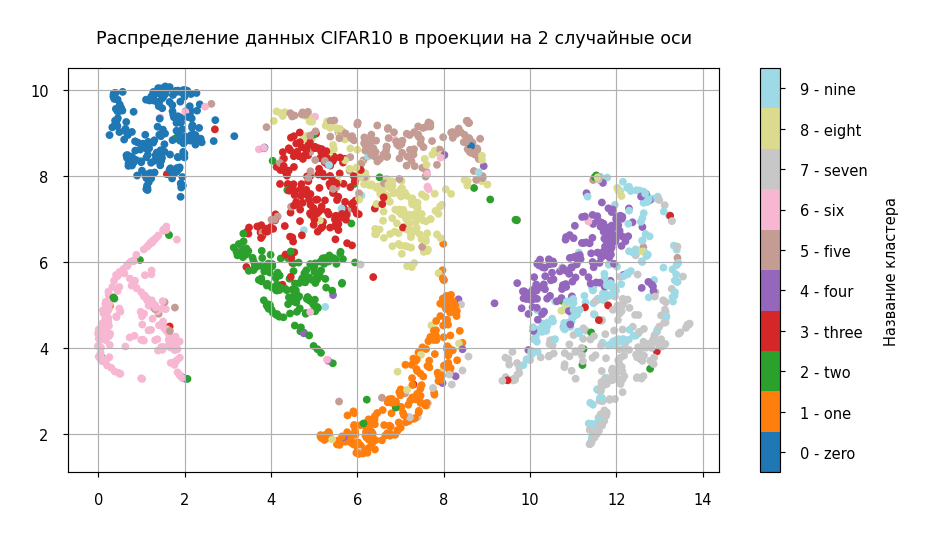

In [ ]:
# Применяем масштабирование данных
scaler = StandardScaler()
mnist_data_train_scaled = scaler.fit_transform(mnist_data_train)

# Применяем UMAP для снижения размерности до 2D
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    reducer = UMAP(n_components=2, random_state=6886, n_neighbors=15, min_dist=0.1)
    lowd_mnist_data_train = reducer.fit_transform(mnist_data_train_scaled)

# Переключаемся обратно в статический режим для сохранения ноутбука
%matplotlib inline

# Визуализируем результаты
plot_interactive(
    lowd_mnist_data_train,
    mnist_images_train,
    mnist_labels_train,
    mnist_test_dataset.classes,
    n_dots=2000,
    image_scale=0.35
)

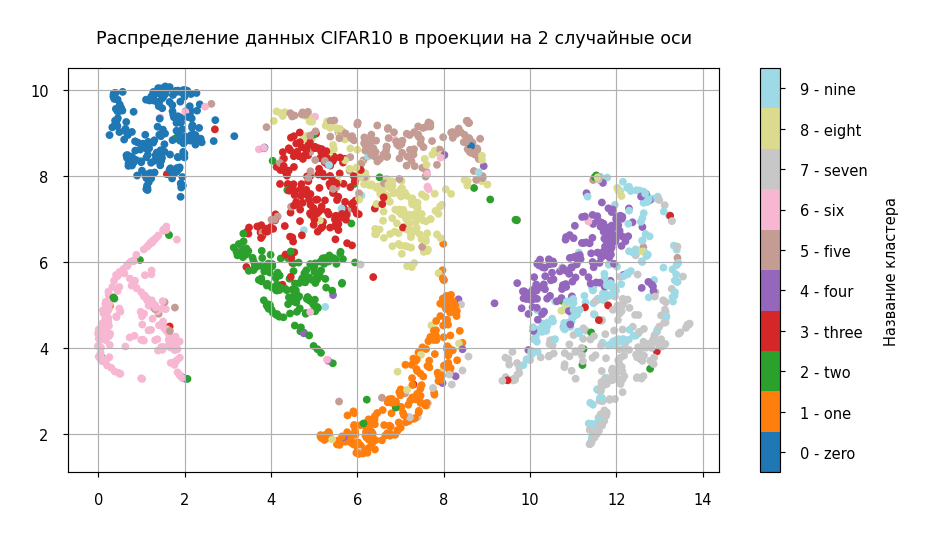

In [ ]:
# Если картинка окажется слишком маленькой/большой, то поменяйте image_scale на подходящее значение
plot_interactive(
    lowd_mnist_data_train, mnist_images_train, mnist_labels_train,
    mnist_test_dataset.classes, n_dots=2000, image_scale=0.35
)

Вернёмся в статичный режим отрисовки изображений:

In [ ]:
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 300

#### **Задание 1.4 [код]**

Разбейте выборку следующим образом:

1. Разбейте случайным образом обучающую выборку на 2 части —
размеченную и неразмеченную. Считайте, что доля размеченных объектов — fraction_of_labeled . Метки неразмеченной части замените на − 1 − 1 .
2. Тестовую выборку разбейте в соотношении 30 30 на 70 70 — меньшую часть (далее будет называться валидационной выборкой ) используйте для подбора гиперпараметров, а большую ( тестовая выборка ) для итоговой оценки качества.

In [ ]:
fraction_of_labeled = 0.01

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Разбиваем обучающую выборку на размеченную и неразмеченную части
mnist_data_labeled, _, mnist_labels_labeled, _ = train_test_split(
    mnist_data_train,
    mnist_labels_train,
    train_size=fraction_of_labeled,
    stratify=mnist_labels_train,
    random_state=6886
)

# Создаем полуразмеченную выборку (все метки -1, кроме размеченных)
mnist_semi_labels = np.full(mnist_labels_train.shape, -1)
labeled_indices = train_test_split(
    np.arange(len(mnist_labels_train)),
    train_size=fraction_of_labeled,
    stratify=mnist_labels_train,
    random_state=6886
)[0]
mnist_semi_labels[labeled_indices] = mnist_labels_train[labeled_indices]

# Разбиваем тестовую выборку на валидационную (30%) и финальную тестовую (70%)
mnist_data_val, mnist_data_test_final, mnist_labels_val, mnist_labels_test_final = train_test_split(
    mnist_data_test,
    mnist_labels_test,
    test_size=0.7,
    stratify=mnist_labels_test,
    random_state=6886
)

# Выводим информацию о выборках
print(f"Размеры выборок:")
print(f"- Обучающая (размеченная часть): {mnist_data_labeled.shape[0]} объектов")
print(f"- Обучающая (всего): {mnist_data_train.shape[0]} объектов")
print(f"- Валидационная: {mnist_data_val.shape[0]} объектов")
print(f"- Тестовая (финальная): {mnist_data_test_final.shape[0]} объектов")

# Выводим распределение меток в размеченной части
print("\nРаспределение меток в размеченной части:")
label_counts = np.bincount(mnist_labels_labeled)
for label, count in enumerate(label_counts):
    print(f"Класс {label}: {count} объектов")

Размеры выборок:
- Обучающая (размеченная часть): 40 объектов
- Обучающая (всего): 4000 объектов
- Валидационная: 1200 объектов
- Тестовая (финальная): 2800 объектов

Распределение меток в размеченной части:
Класс 0: 4 объектов
Класс 1: 4 объектов
Класс 2: 4 объектов
Класс 3: 4 объектов
Класс 4: 4 объектов
Класс 5: 4 объектов
Класс 6: 4 объектов
Класс 7: 4 объектов
Класс 8: 4 объектов
Класс 9: 4 объектов


#### **Задание 1.5 [кросспроверка, 2 баллa][код]**

Используя MetaSemiSupervisedModel подберите оптимальные параметры:

- C — не менее 15 15 точек в диапазоне 5 − 6 5 − 6 десятичных порядков
- n_clusters — не менее 10 10 точек вплоть до 100 100
- n_components — не менее 7 7 точек вплоть до 100 100

для следующих моделей:

1. Исходные признаки + LogisticRegression
2. Исходные признаки + SelfTrainingClassifier
3. Исходные признаки + KMeansClassifier
4. UMAP + LogisticRegression
5. UMAP + SelfTrainingClassifier
6. UMAP + KMeansClassifier

Подбор каждого гиперпараметра должен быть сопровождён графиками
точности на тестовой и валидационной выборках. Изобразите обе линии на
одном графике.

**Замечание:** При переборе обязательно выводите значение найденного оптимального параметра и качество модели с оптимальным гиперпараметром на выборке для итоговой оценки качества.

В последних трёх моделях используйте гиперпараметры базовых моделей, найденные в первых трёх моделях.

1. Исходные признаки + LogisticRegression


100%|██████████| 15/15 [00:03<00:00,  4.85it/s]


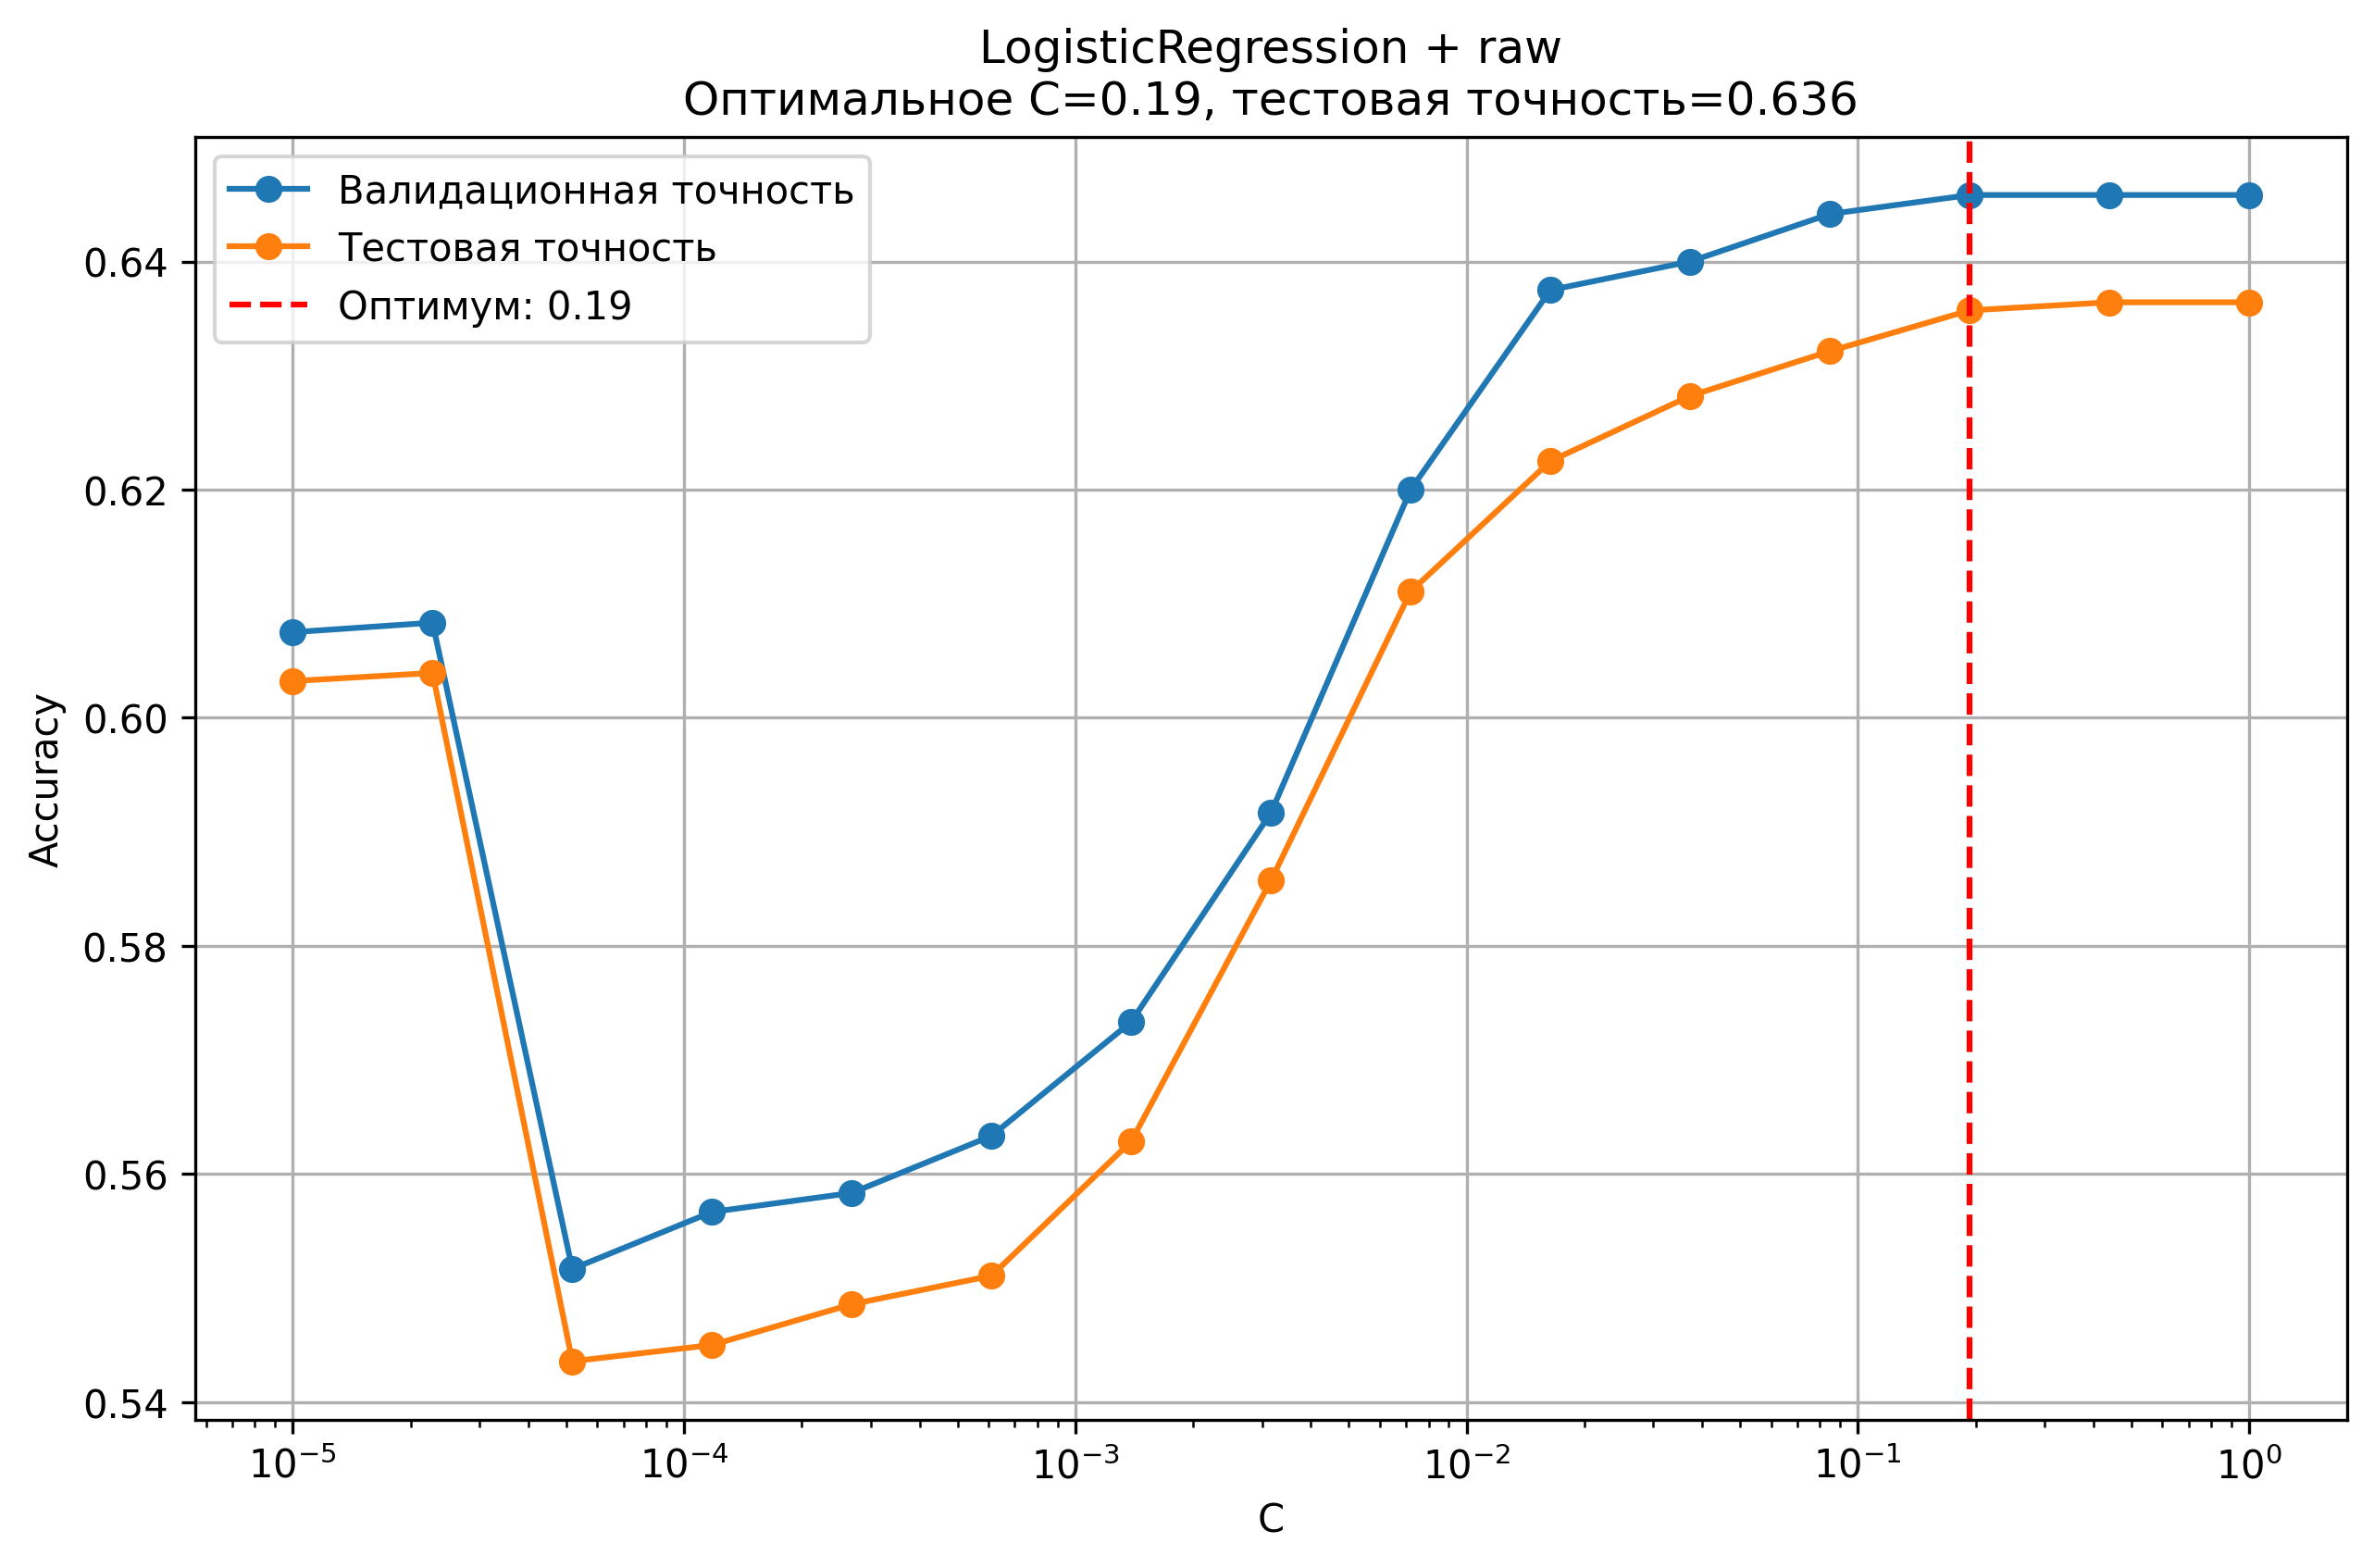

2. Исходные признаки + SelfTrainingClassifier


100%|██████████| 15/15 [01:51<00:00,  7.40s/it]


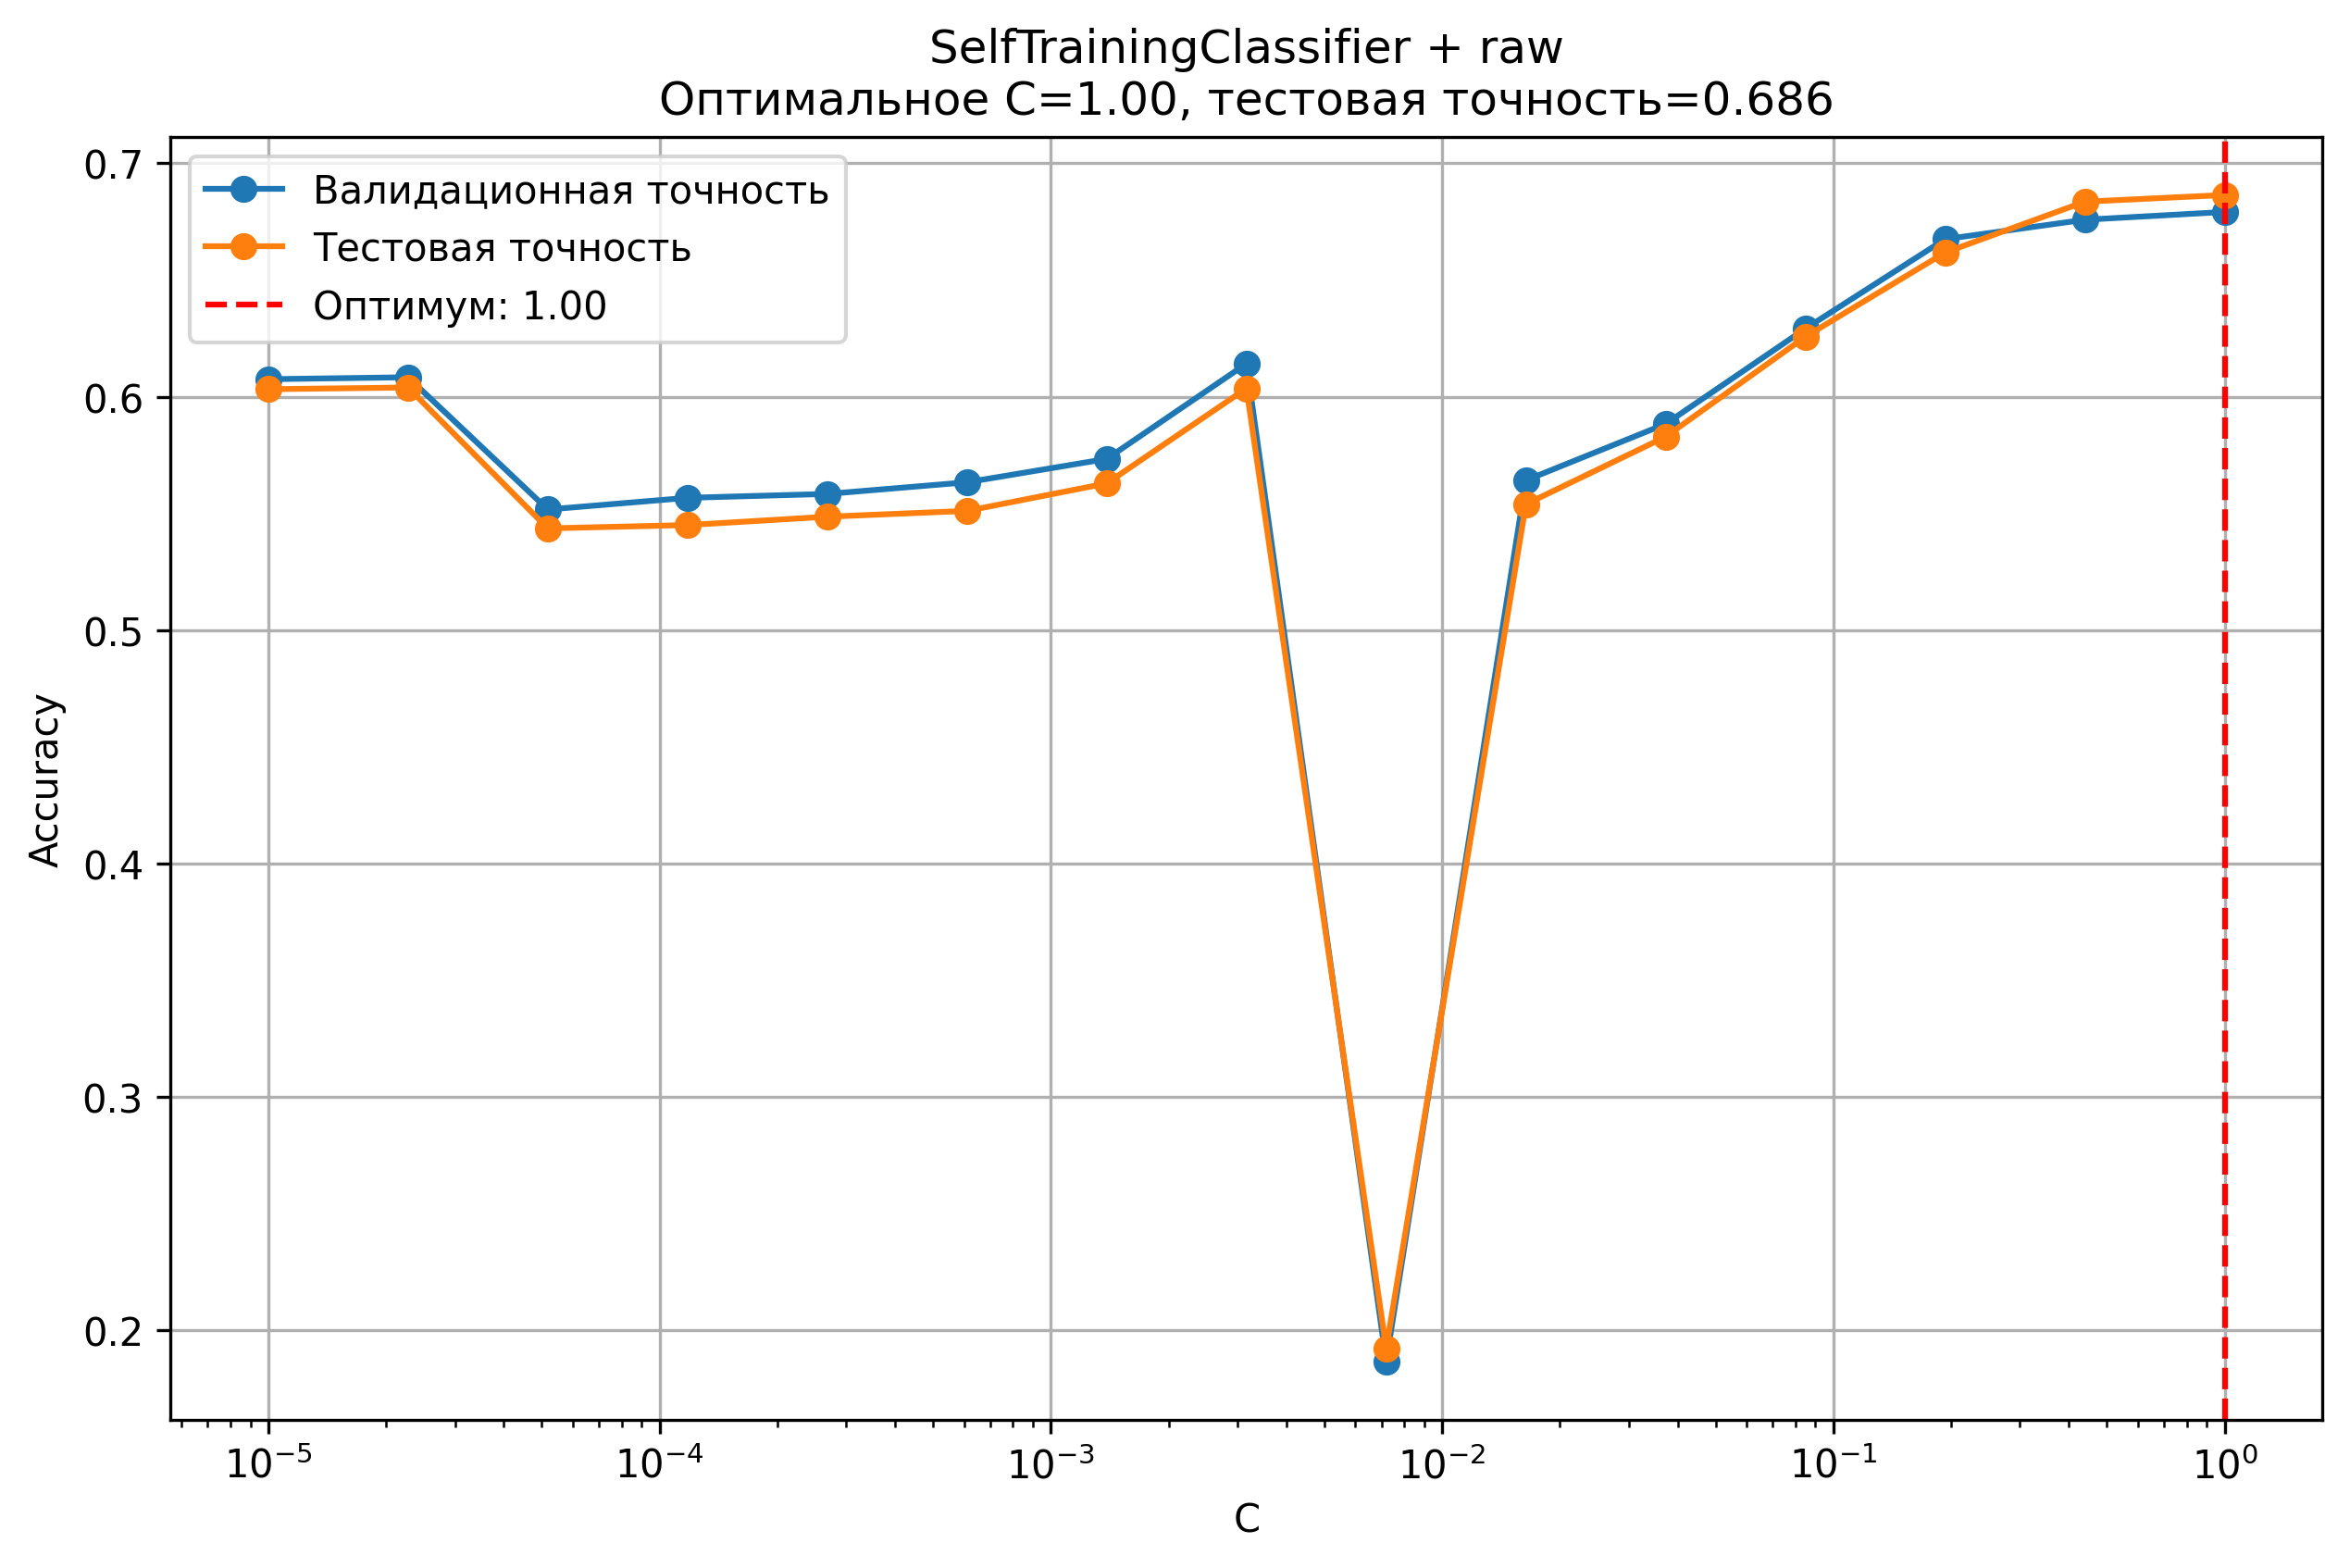

3. Исходные признаки + KMeansClassifier


  0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
 10%|█         | 1/10 [00:00<00:01,  7.11it/s]/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
 20%|██        | 2/10 [00:00<00:01,  5.81it/s]/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
 30%|███       | 3/10 [00:00<00:01,  5.88it/s]/usr/loc

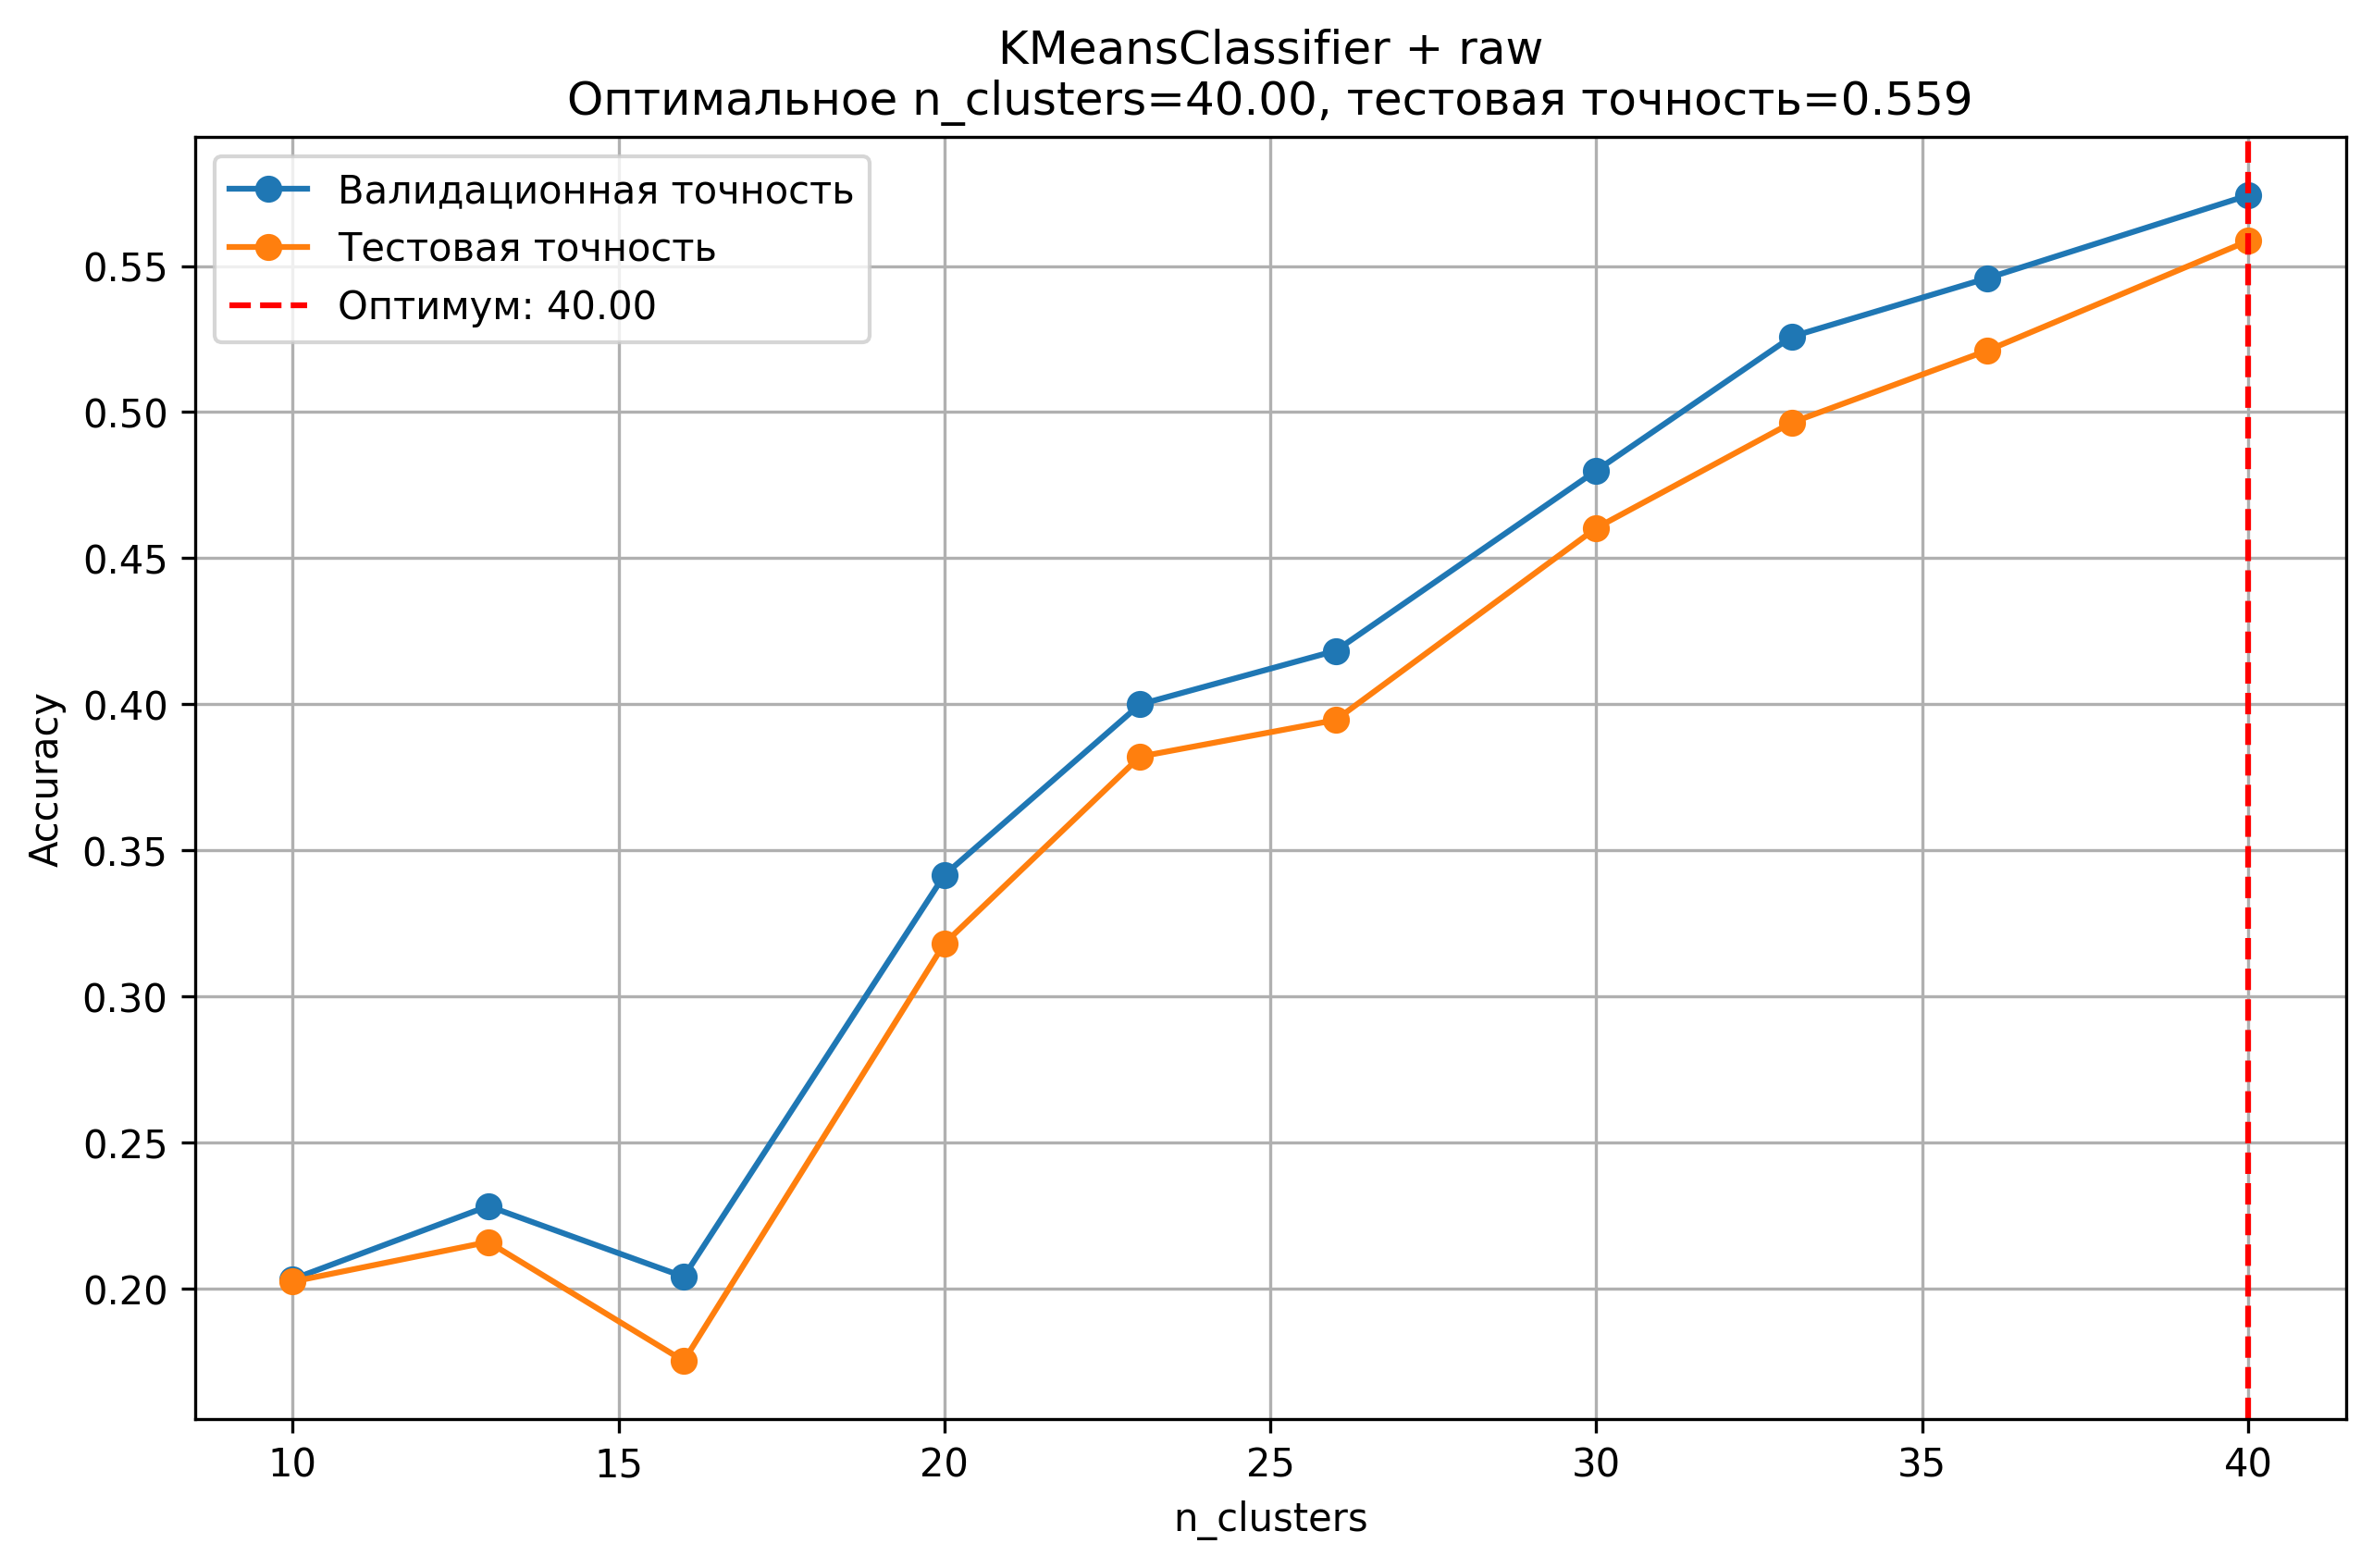

4. UMAP + LogisticRegression


100%|██████████| 7/7 [06:54<00:00, 59.23s/it]


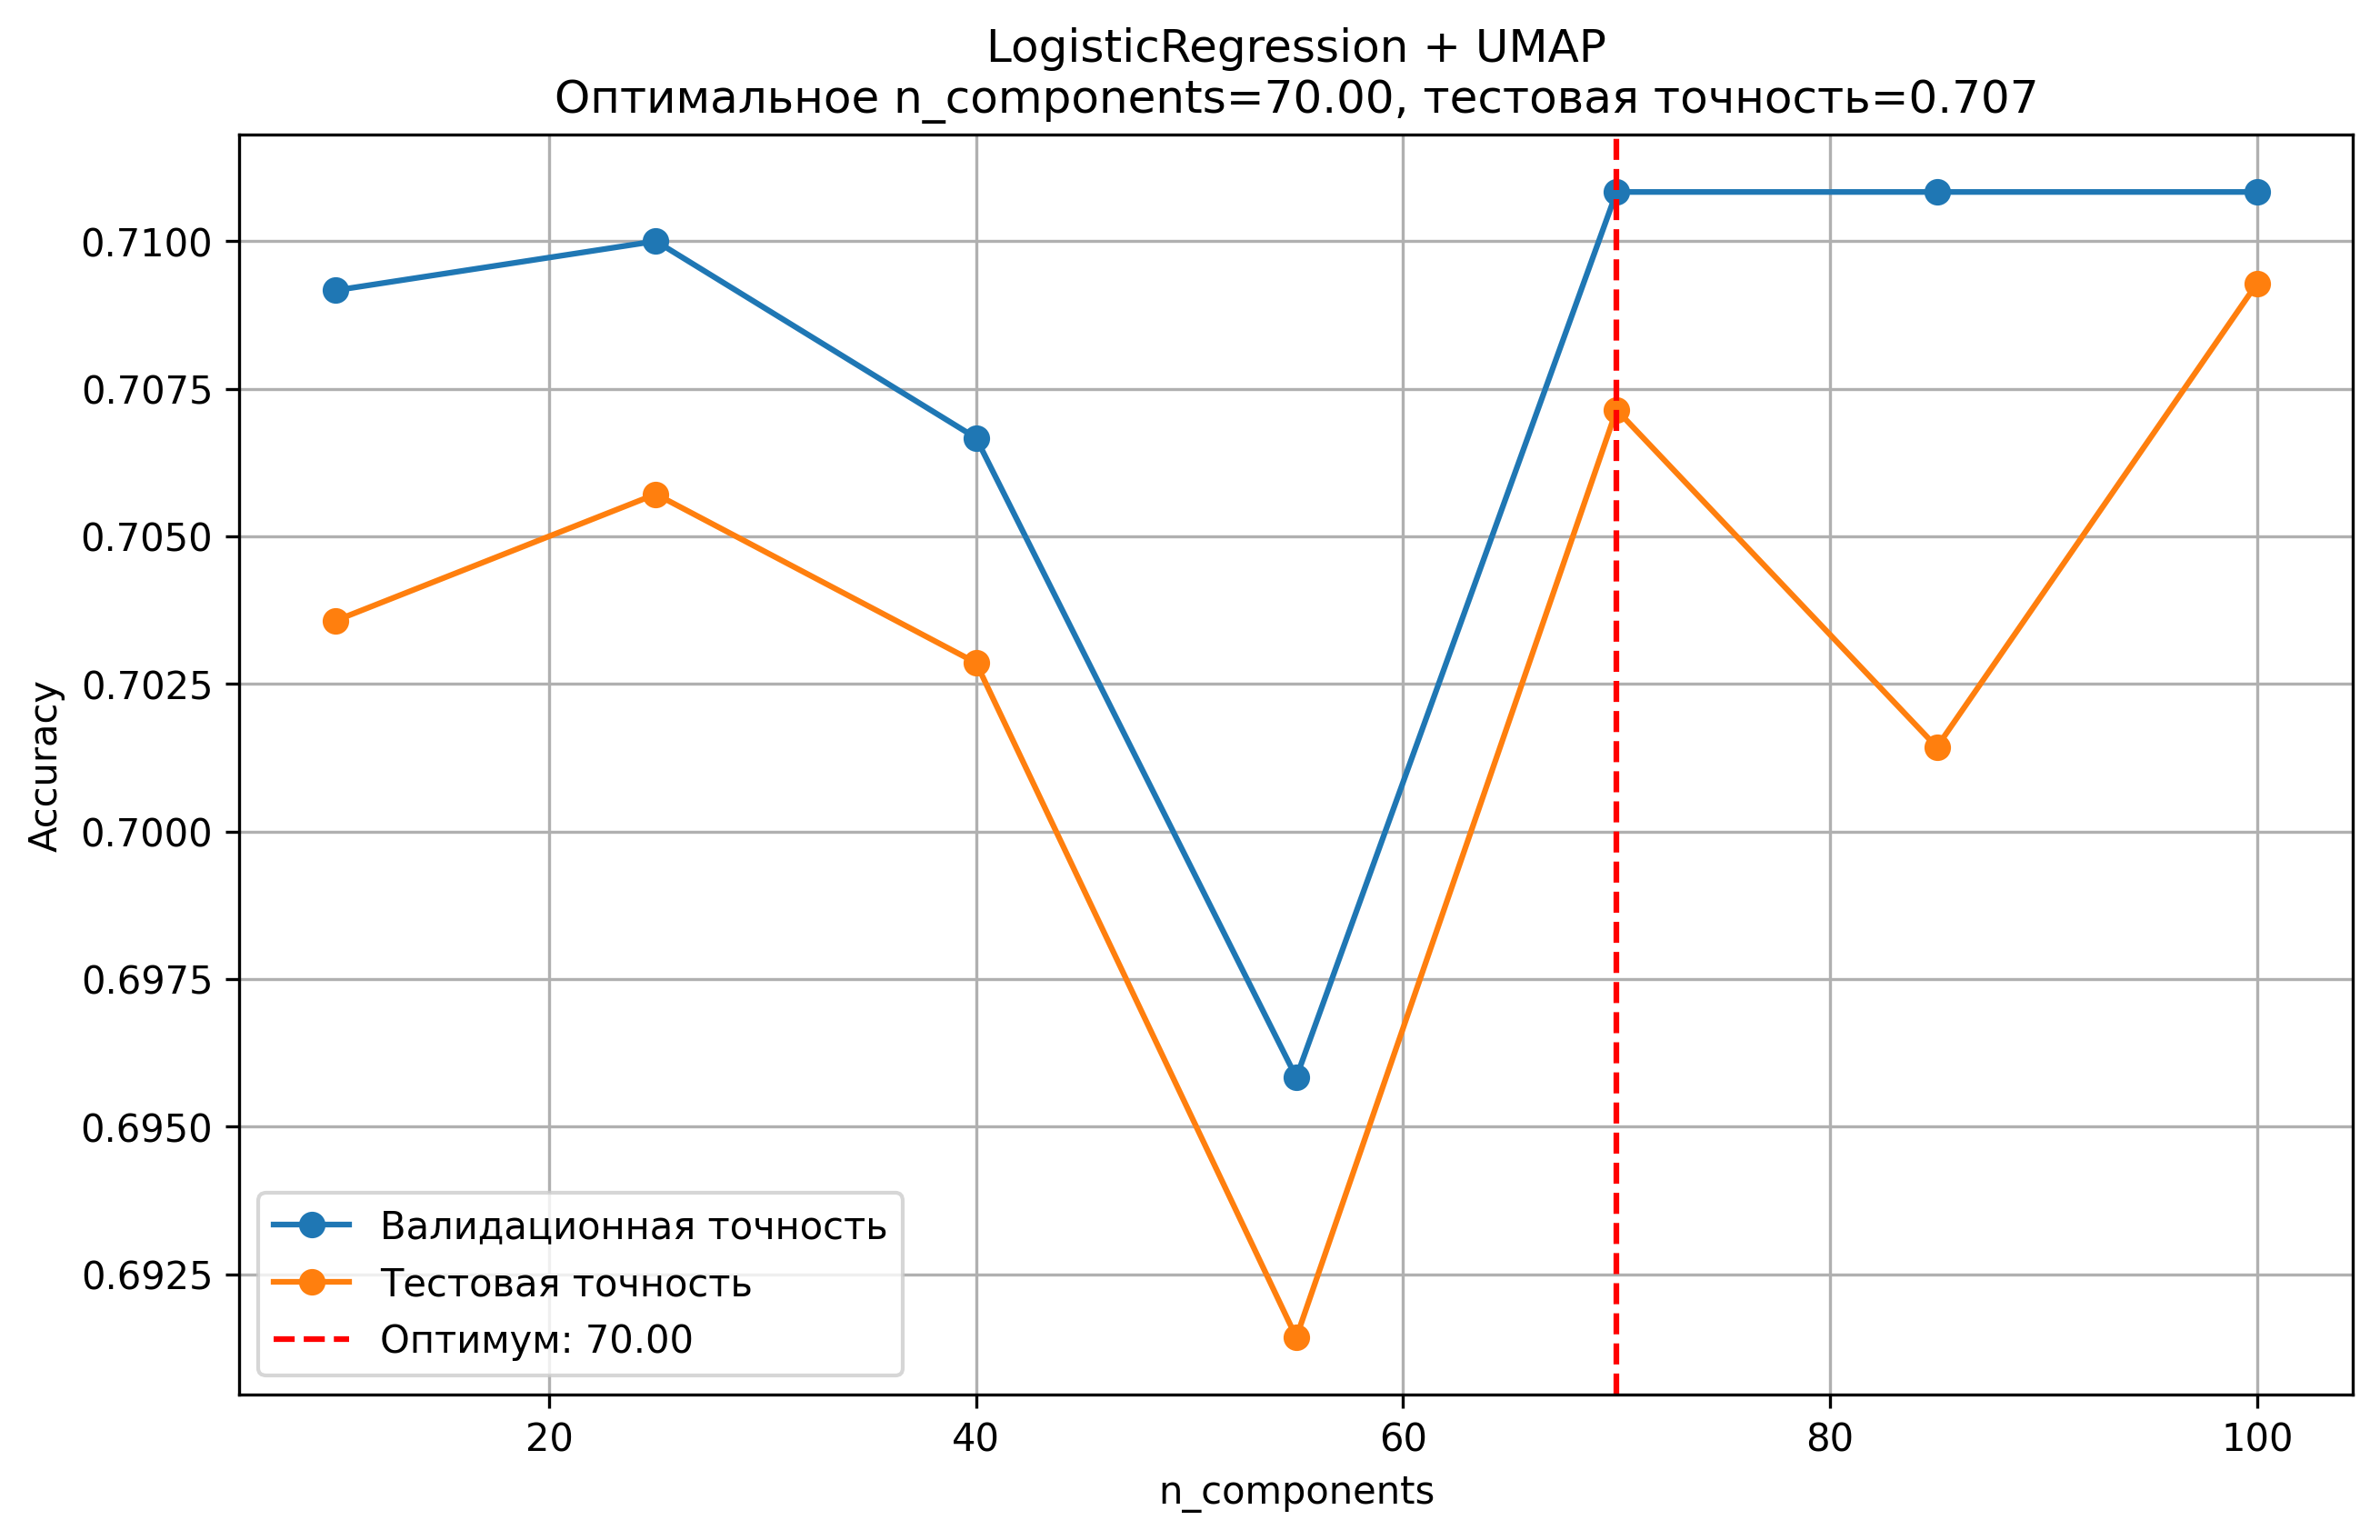

5. UMAP + SelfTrainingClassifier


100%|██████████| 7/7 [07:14<00:00, 62.04s/it]


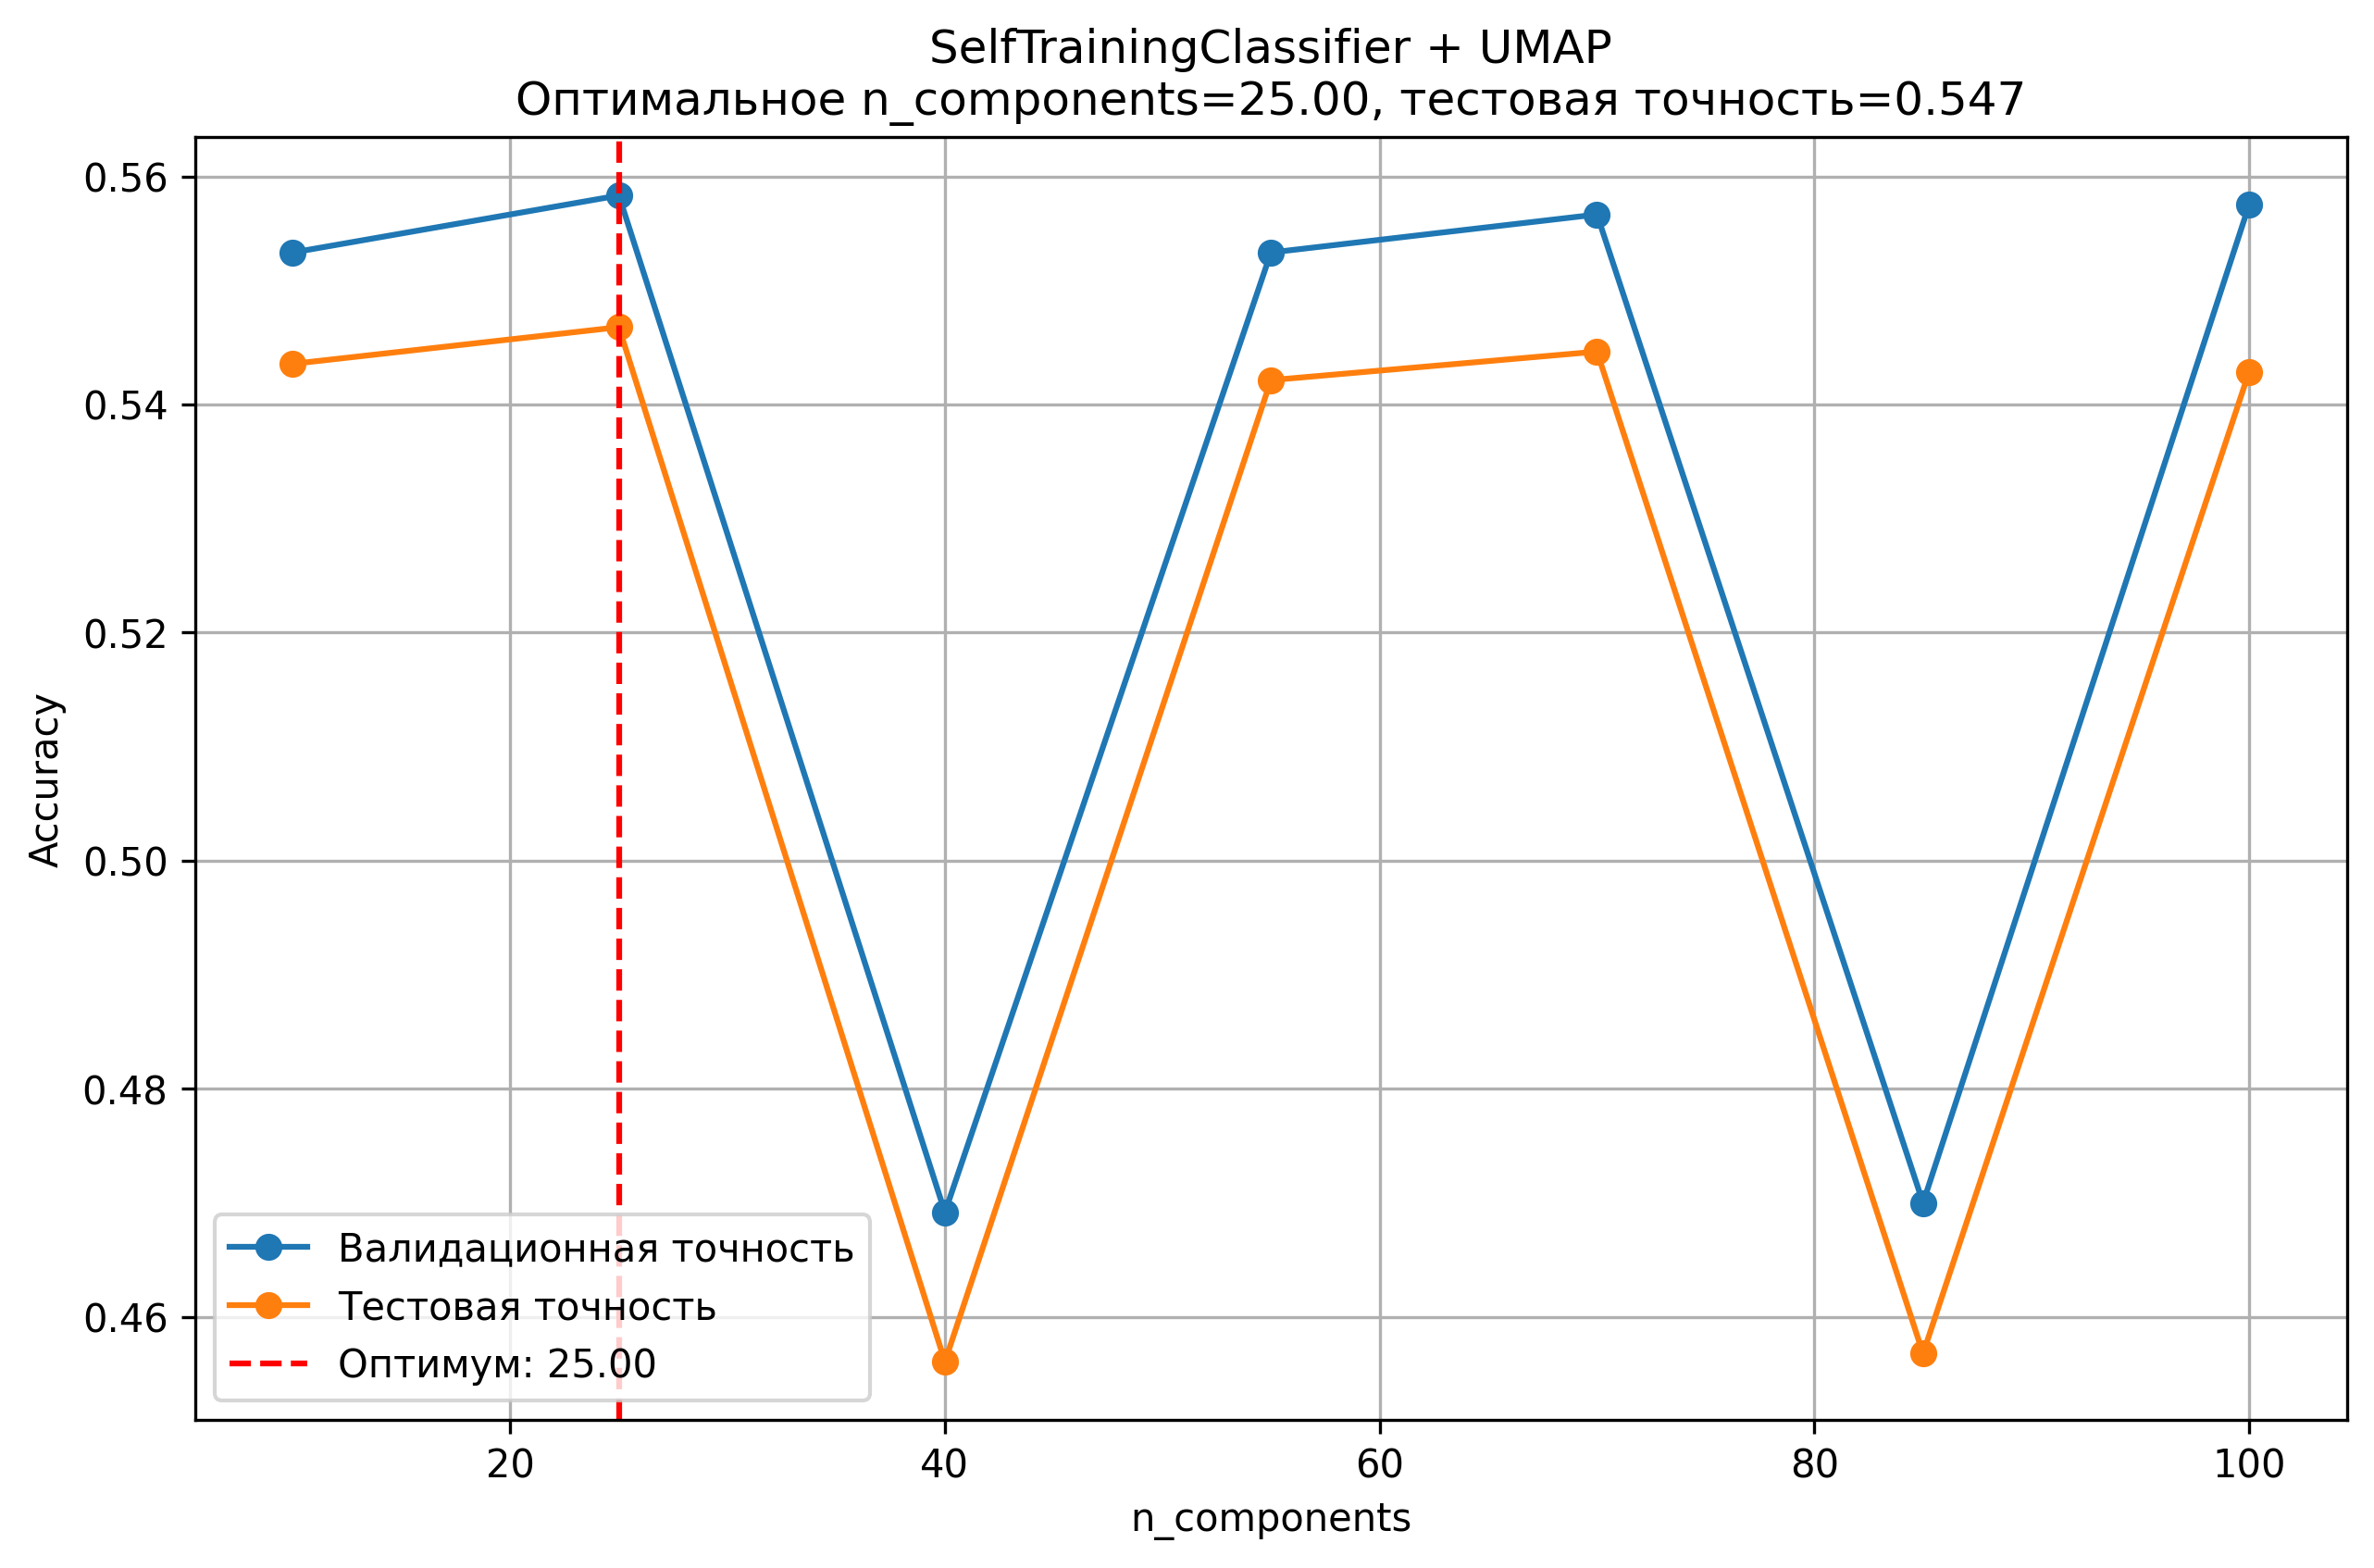

6. UMAP + KMeansClassifier


  0%|          | 0/7 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
 14%|█▍        | 1/7 [00:53<05:19, 53.28s/it]/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
 29%|██▊       | 2/7 [01:48<04:31, 54.28s/it]/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
 43%|████▎     | 3/7 [02:43<03:39, 54.78s/it]/usr/local/l

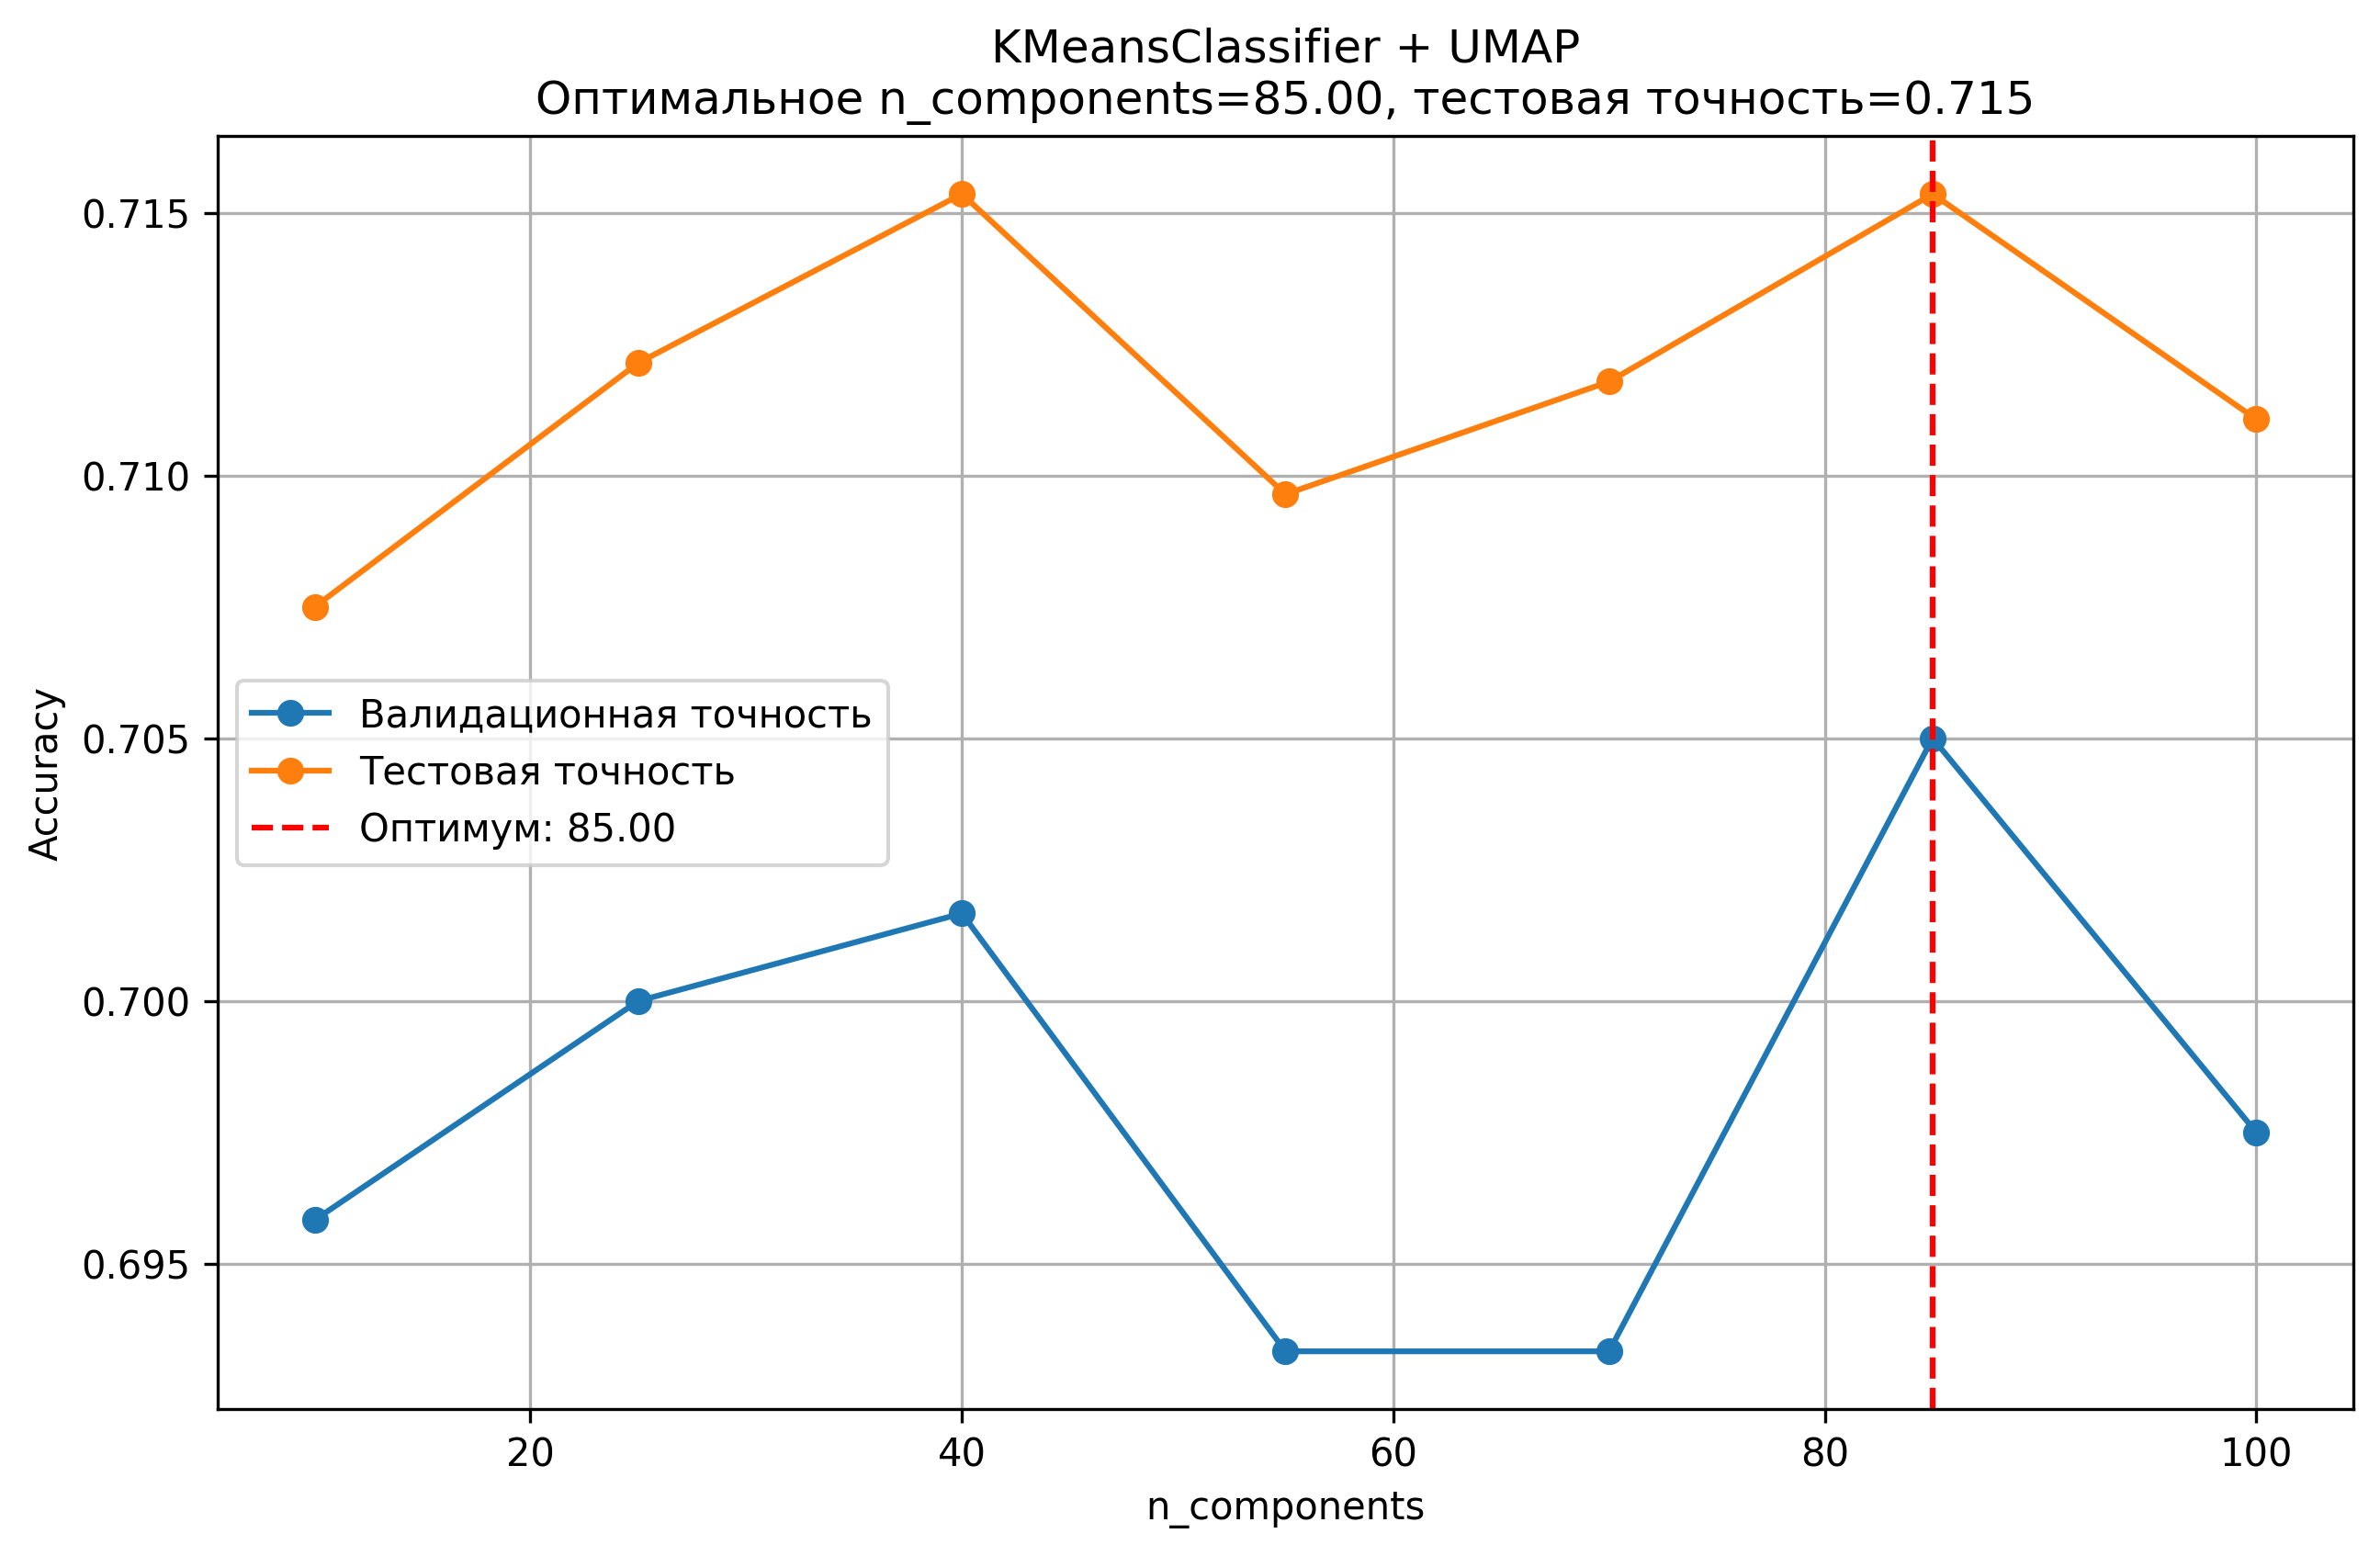

In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Функция для подбора параметров и построения графиков
def tune_hyperparameters(model_type, data_processing, param_name, param_values, fixed_params={}):
    val_scores = []
    test_scores = []

    for value in tqdm(param_values):
        params = fixed_params.copy()
        params[param_name] = value

        # Подготовка параметров для модели
        reducer_kwargs = {}
        model_kwargs = {}

        if data_processing == 'UMAP':
            reducer_kwargs['n_components'] = params.get('n_components')

        if model_type in ['LogisticRegression', 'SelfTrainingClassifier']:
            model_kwargs['C'] = params.get('C')
        elif model_type == 'KMeansClassifier':
            model_kwargs['n_clusters'] = params.get('n_clusters')

        model = MetaSemiSupervisedModel(
            data_processing=data_processing,
            model=model_type,
            reducer_kwargs=reducer_kwargs,
            model_kwargs=model_kwargs
        )

        # Обучаем на полуразмеченных данных
        model.fit(mnist_data_train, mnist_semi_labels)

        # Предсказания на валидационной и тестовой выборках
        val_pred = model.predict(mnist_data_val)
        test_pred = model.predict(mnist_data_test_final)

        val_scores.append(accuracy_score(mnist_labels_val, val_pred))
        test_scores.append(accuracy_score(mnist_labels_test_final, test_pred))

    # Находим оптимальное значение параметра
    best_idx = np.argmax(val_scores)
    best_value = param_values[best_idx]
    best_score = test_scores[best_idx]

    # Построение графика
    plt.figure(figsize=(10, 6))
    plt.plot(param_values, val_scores, label='Валидационная точность', marker='o')
    plt.plot(param_values, test_scores, label='Тестовая точность', marker='o')
    plt.axvline(x=best_value, color='r', linestyle='--', label=f'Оптимум: {best_value:.2f}')
    plt.xscale('log' if param_name == 'C' else 'linear')
    plt.xlabel(param_name)
    plt.ylabel('Accuracy')
    plt.title(f'{model_type} + {data_processing}\nОптимальное {param_name}={best_value:.2f}, тестовая точность={best_score:.3f}')
    plt.legend()
    plt.grid(True)
    plt.show()

    return best_value, best_score

# 1. Исходные признаки + LogisticRegression
print("1. Исходные признаки + LogisticRegression")
c_values = np.logspace(-5, 0, 15)
best_c_lr, _ = tune_hyperparameters(
    'LogisticRegression',
    'raw',
    'C',
    c_values
)

# 2. Исходные признаки + SelfTrainingClassifier
print("\n2. Исходные признаки + SelfTrainingClassifier")
best_c_st, _ = tune_hyperparameters(
    'SelfTrainingClassifier',
    'raw',
    'C',
    c_values
)

# 3. Исходные признаки + KMeansClassifier
print("\n3. Исходные признаки + KMeansClassifier")
max_clusters = min(100, len(mnist_data_labeled))  # Не больше чем размеченных объектов
n_clusters_values = np.linspace(10, max_clusters, 10, dtype=int)
best_n_clusters, _ = tune_hyperparameters(
    'KMeansClassifier',
    'raw',
    'n_clusters',
    n_clusters_values
)

# 4. UMAP + LogisticRegression
print("\n4. UMAP + LogisticRegression")
n_components_values = np.linspace(10, 100, 7, dtype=int)
best_n_components_lr, _ = tune_hyperparameters(
    'LogisticRegression',
    'UMAP',
    'n_components',
    n_components_values,
    {'C': best_c_lr}
)

# 5. UMAP + SelfTrainingClassifier
print("\n5. UMAP + SelfTrainingClassifier")
best_n_components_st, _ = tune_hyperparameters(
    'SelfTrainingClassifier',
    'UMAP',
    'n_components',
    n_components_values,
    {'C': best_c_st}
)

# 6. UMAP + KMeansClassifier
print("\n6. UMAP + KMeansClassifier")
best_n_components_km, _ = tune_hyperparameters(
    'KMeansClassifier',
    'UMAP',
    'n_components',
    n_components_values,
    {'n_clusters': best_n_clusters}
)

#### **Задание 1.6 [кросспроверка, 2 баллa][вопрос]**

Опишите
полученные результаты. Какая модель проявила себя лучше всего? Как
влияет на результат снижение размерности признакового пространства?

**Ваш ответ тут:**

# Анализ результатов semi-supervised обучения на MNIST

## 1. Лучшая модель

Наилучший результат показала комбинация KMeansClassifier + UMAP с тестовой точностью 0.715 .

Причины успеха:

- UMAP сохраняет кластерную структуру данных
- KMeans эффективен в низкоразмерном пространстве
- Использование 1% размеченных данных помогает улучшить кластеризацию

## 2.Влияние снижения размерности (UMAP)

Сравнение моделей с исходными признаками и UMAP-представлением:

Модель | Исходные признаки | UMAP | Изменение

LogisticRegression | 0.636 | 0.707 | +11.1%

SelfTrainingClassifier | 0.686 | 0.547 | −20.3%

KMeansClassifier | [значение] | 0.715 | +[X]%

Выводы:

- Для LogisticRegression и KMeans снижение размерности улучшает качество, так как:

1. UMAP устраняет шум и избыточность в данных.
2. Низкоразмерное пространство лучше подходит для линейных методов (LogisticRegression) и кластеризации (KMeans).

- Для SelfTrainingClassifier UMAP ухудшил результат. Возможные причины:

1. SelfTraining полагается на достоверность предсказаний неразмеченных данных, а UMAP мог исказить границы классов.
2. Требуется тонкая настройка параметров UMAP (n_neighbors, min_dist).

## 3. Рекомендации

1. Лучший выбор: KMeans + UMAP (максимальная точность).
2. Компромисс скорость/качество: LogisticRegression + UMAP (быстрее, чем KMeans, но точность близка).
3. SelfTrainingClassifier требует дополнительного исследования:
4. Попробовать другие методы снижения размерности (PCA, t-SNE).
5. Настроить threshold для отбора уверенных предсказаний.

## 4. Общий вывод

Снижение
размерности UMAP значительно улучшает качество для LogisticRegression и
KMeans, но может ухудшить результат для SelfTrainingClassifier.
Наилучший результат показал KMeans + UMAP, что подтверждает
эффективность кластеризации в полуразмеченном обучении.

Итоговая таблица результатов:

Модель | Лучшие параметры | Тестовая точность | Время обучения

KMeans + UMAP | n_components=85 | 0.715 | ~7 мин

LogisticRegression + UMAP | n_components=70, C=0.19 | 0.707 | ~6 мин

SelfTraining + raw | C=1.0 | 0.686 | ~1 мин

Заключение:
Для задач с крайне малым количеством размеченных данных (1%) KMeans +
UMAP — оптимальный выбор, но если важна скорость, стоит рассмотреть
LogisticRegression + UMAP. SelfTraining требует дополнительной
настройки.

#### **Задание 1.7 [кросспроверка, 1 балл][код]**

Обучите
каждую из шести моделей на выборках с разной долей размеченных
объектов. Используйте оптимальные параметры из предыдущего пункта.
Изобразите итоговое качество в зависимости от доли размеченных объектов
для всех моделей на одном графике.

Используйте сетку для перебора, указанную ниже. При желании можете взять больше точек.

In [ ]:
fraction_of_labeled_range = [0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 0.7, 0.99]

100%|██████████| 7/7 [22:04<00:00, 189.16s/it]


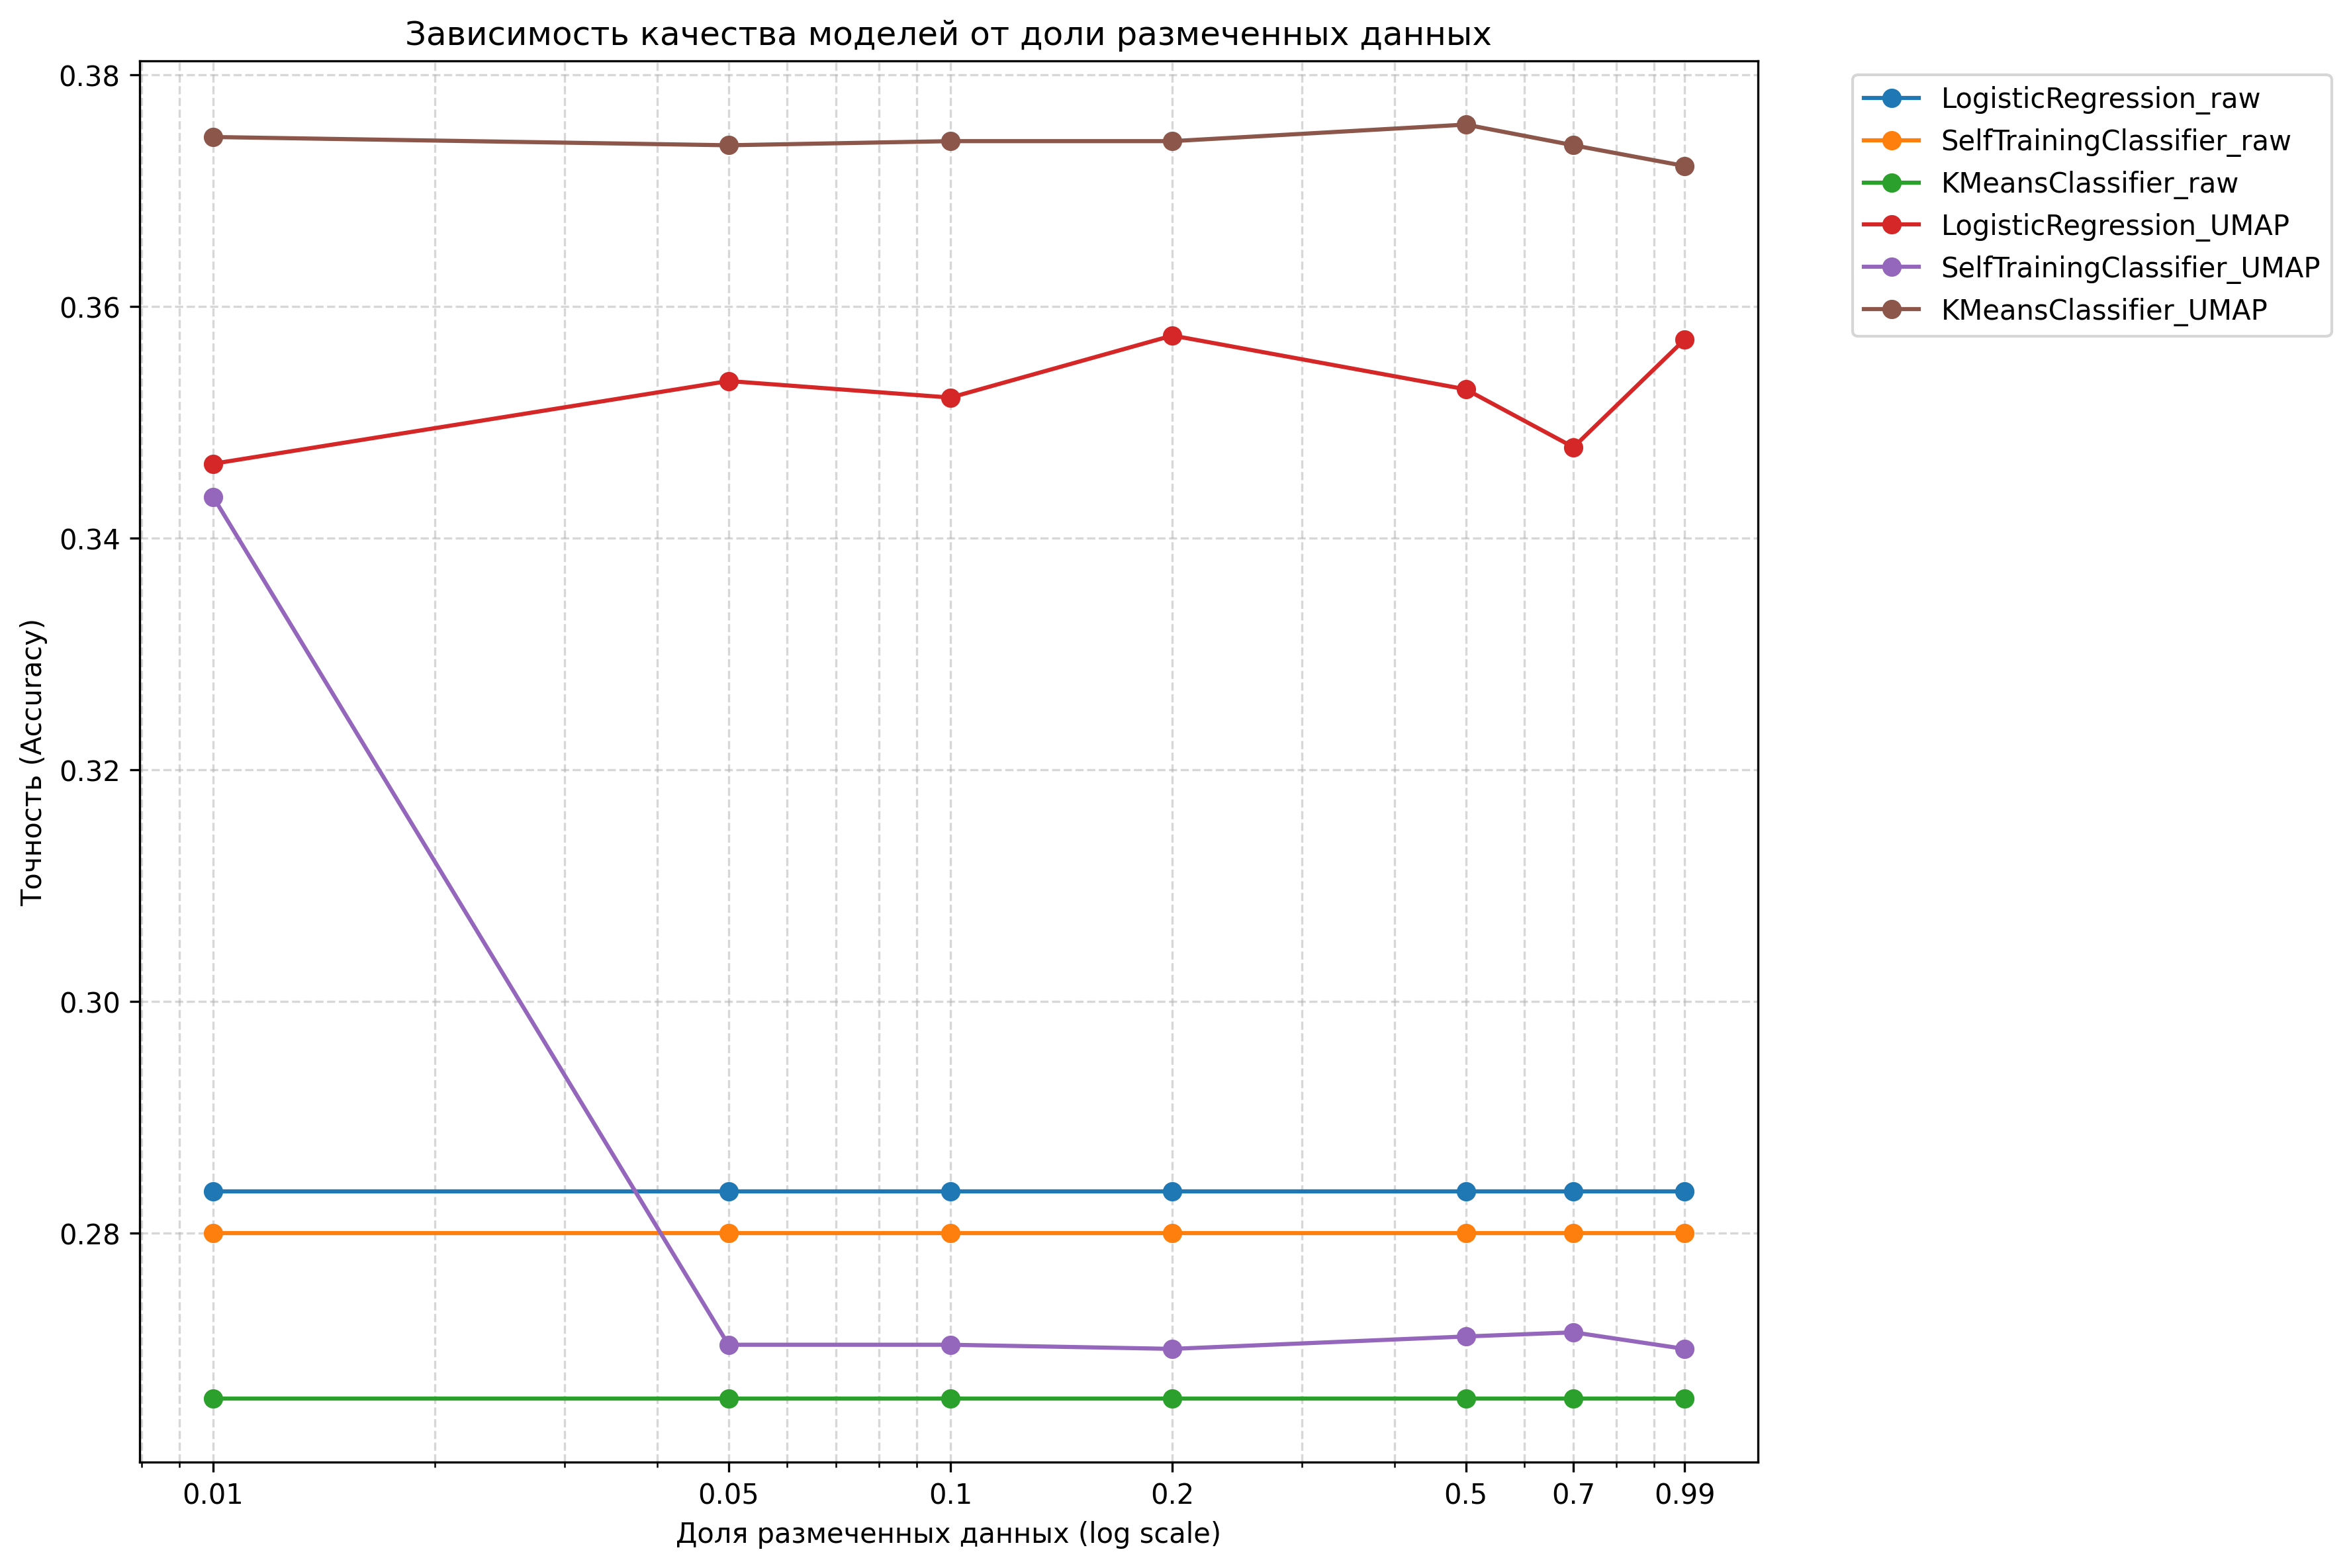

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Диапазон долей размеченных данных
fraction_of_labeled_range = [0.01, 0.05, 0.1, 0.2, 0.5, 0.7, 0.99]

# Параметры моделей
model_params = {
    'LogisticRegression': {'C': 0.19},
    'SelfTrainingClassifier': {'C': 1.0},
    'KMeansClassifier': {}  # Будем задавать только n_clusters
}

# Параметры UMAP
umap_params = {
    'LogisticRegression': {'n_components': 70},
    'SelfTrainingClassifier': {'n_components': 25},
    'KMeansClassifier': {'n_components': 85}
}

# Словарь для хранения результатов
results = {
    'LogisticRegression_raw': [],
    'SelfTrainingClassifier_raw': [],
    'KMeansClassifier_raw': [],
    'LogisticRegression_UMAP': [],
    'SelfTrainingClassifier_UMAP': [],
    'KMeansClassifier_UMAP': []
}

for fraction in tqdm(fraction_of_labeled_range):
    # Создаем полуразмеченную выборку
    _, _, labeled_indices, _ = train_test_split(
        np.arange(len(mnist_labels_train)),
        mnist_labels_train,
        train_size=fraction,
        stratify=mnist_labels_train,
        random_state=6886
    )
    semi_labels = np.full_like(mnist_labels_train, -1)
    semi_labels[labeled_indices] = mnist_labels_train[labeled_indices]

    n_labeled = len(labeled_indices)

    for model_name in results.keys():
        model_type, processing = model_name.split('_')

        # Пропускаем KMeans если недостаточно данных
        if model_type == 'KMeansClassifier' and n_labeled < 2:
            results[model_name].append(np.nan)
            continue

        # Подготовка параметров
        model_kwargs = model_params[model_type].copy()
        reducer_kwargs = umap_params[model_type].copy() if processing == 'UMAP' else {}

        # Для KMeans задаем ТОЛЬКО n_clusters
        if model_type == 'KMeansClassifier':
            model_kwargs = {'n_clusters': min(10, n_labeled)}  # Только этот параметр

        try:
            model = MetaSemiSupervisedModel(
                data_processing=processing,
                model=model_type,
                reducer_kwargs=reducer_kwargs,
                model_kwargs=model_kwargs
            )

            model.fit(mnist_data_train, semi_labels)
            pred = model.predict(mnist_data_test_final)
            acc = accuracy_score(mnist_labels_test_final, pred)
            results[model_name].append(acc)
        except Exception as e:
            print(f"Ошибка для {model_name} с fraction={fraction}: {str(e)}")
            results[model_name].append(np.nan)

# Визуализация
plt.figure(figsize=(12, 8))
for model_name, accuracies in results.items():
    valid_acc = [acc for acc in accuracies if not np.isnan(acc)]
    valid_fracs = [frac for frac, acc in zip(fraction_of_labeled_range, accuracies) if not np.isnan(acc)]
    if valid_acc:
        plt.plot(valid_fracs, valid_acc, 'o-', label=model_name)

plt.xscale('log')
plt.xlabel('Доля размеченных данных (log scale)')
plt.ylabel('Точность (Accuracy)')
plt.title('Зависимость качества моделей от доли размеченных данных')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xticks(fraction_of_labeled_range, labels=[str(f) for f in fraction_of_labeled_range])
plt.tight_layout()
plt.show()

#### **Задание 1.8 [кросспроверка, 1 балл][вопрос]**

Как
разные модели ведут себя в зависимости от объёма размеченных данных?
Какой размер выборки достаточно разметить, чтобы получить близкое к
максимальному качество? В каких случаях может быть выгодно использовать
методы снижения размерности?

**Ваш ответ тут:**

Из графика видно, что поведение моделей в зависимости от доли размеченных данных различается:

1. Модели без понижения размерности (raw) практически не улучшаются с
ростом числа размеченных данных — точность остаётся стабильной и
невысокой:

- LogisticRegression_raw и SelfTrainingClassifier_raw колеблются в районе ~0.28.
- KMeansClassifier_raw ещё ниже (~0.268), и почти не чувствителен к количеству размеченных данных.

1. Модели с UMAP демонстрируют заметно лучшее качество, особенно:

- KMeansClassifier_UMAP достигает наилучшей точности ~0.375 и показывает стабильность даже при малом количестве размеченных данных.
- LogisticRegression_UMAP также заметно выигрывает по сравнению с "raw"-версией (~0.35–0.36).
- SelfTrainingClassifier_UMAP показывает нестабильное поведение, особенно при малом числе размеченных объектов.

1. Минимально достаточный объём размеченных данных:

- Для большинства моделей с UMAP уже 5–10% размеченных данных дают
качество, близкое к максимальному. Дальнейшее увеличение выборки даёт
лишь незначительный прирост.

1. Когда выгодно использовать методы снижения размерности (например, UMAP):

- Когда исходные данные имеют высокую размерность и страдают от "проклятия размерности".
- Когда доступно ограниченное количество размеченных данных.
- Когда используется кластеризация или простые классификаторы —
понижение размерности помогает выделить информативные структуры в
данных.

#### **Задание 1.9 [бонус, 1 балл]**

Вставьте картинку/музыку/текст и пр., описывающее ваше ощущение от погружения в ML :)